# Notebook Storytelling Visual Externo — Parcial MLOps

**Versión v10 FINAL CON ESPECIFICACIONES.**  
Incluye storytelling, evaluación offline, TLV, umbrales, monitoreo operativo, speed-up por paralelismo y comparación de configuraciones **rápida vs completa**.


In [1]:
# ============================================================
# 0. Configuración general
# ============================================================

from pathlib import Path
import json
import re
import math
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# Si el notebook no está dentro de la raíz del proyecto, pega aquí la ruta manual.
# Ejemplo:
# PROJECT_ROOT_MANUAL = r"C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_Gariazzo_FINAL"
PROJECT_ROOT_MANUAL = None

def buscar_raiz_proyecto():
    """Busca la raíz del proyecto desde el directorio actual."""
    if PROJECT_ROOT_MANUAL:
        p = Path(PROJECT_ROOT_MANUAL).expanduser().resolve()
        if p.exists():
            return p
        raise FileNotFoundError(f"No existe PROJECT_ROOT_MANUAL: {p}")

    actual = Path.cwd().resolve()
    candidatos = [actual] + list(actual.parents)
    for p in candidatos:
        if (p / "src").exists() or (p / "training_pipeline.py").exists() or (p / "inference_pipeline.py").exists():
            return p
    return actual

PROJECT_ROOT = buscar_raiz_proyecto()

DIR_REPORTS = PROJECT_ROOT / "reports"
DIR_FIG = DIR_REPORTS / "figures_storytelling"
DIR_TABLES = DIR_REPORTS / "tables_storytelling"
DIR_LOGS = PROJECT_ROOT / "logs"
DIR_OUTPUT = PROJECT_ROOT / "output"
DIR_DATA = PROJECT_ROOT / "data"
DIR_SRC = PROJECT_ROOT / "src"

DIR_FIG.mkdir(parents=True, exist_ok=True)
DIR_TABLES.mkdir(parents=True, exist_ok=True)

# Paleta consistente para PPT.
COLOR_AZUL = "#1f4e79"
COLOR_AZUL_OSCURO = "#2f4054"
COLOR_VERDE = "#70ad47"
COLOR_VERDE_OSCURO = "#006b5b"
COLOR_NARANJA = "#ed7d31"
COLOR_GRIS = "#a6a6a6"
COLOR_GRIS_OSCURO = "#6b7a8a"
COLOR_ROJO = "#c00000"
COLOR_MORADO = "#7b3fe4"

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 180,
    "font.size": 11,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def guardar_figura(nombre):
    path = DIR_FIG / nombre
    plt.savefig(path, bbox_inches="tight", facecolor="white")
    print(f"Figura guardada: {path}")

def guardar_tabla(df, nombre):
    path = DIR_TABLES / nombre
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"Tabla guardada: {path}")

def titulo(ax, texto, subtitulo=None):
    ax.set_title(texto, color=COLOR_AZUL, pad=16, fontsize=18, fontweight="bold")
    if subtitulo:
        ax.text(
            0.5, 1.01, subtitulo,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            color="#555555",
            fontsize=10
        )

def leer_json(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def archivo_mas_reciente(patrones, base=PROJECT_ROOT):
    archivos = []
    for patron in patrones:
        archivos.extend(base.glob(patron))
    archivos = [p for p in archivos if p.is_file()]
    if not archivos:
        return None
    return max(archivos, key=lambda p: p.stat().st_mtime)

def leer_csv_seguro(path, **kwargs):
    if path is None or not Path(path).exists():
        return None
    try:
        return pd.read_csv(path, **kwargs)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin1", **kwargs)

display(Markdown(f"""
**Raíz detectada del proyecto:** `{PROJECT_ROOT}`  
**Figuras:** `{DIR_FIG}`  
**Tablas:** `{DIR_TABLES}`
"""))


**Raíz detectada del proyecto:** `C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL`  
**Figuras:** `C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling`  
**Tablas:** `C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling`


## 1. Carga de artefactos

Esta sección intenta encontrar automáticamente los archivos generados por el pipeline:

- `reports/tables/*.csv`
- `output/scores_*.csv`
- `logs/*.log`
- `src/variables.py`
- `best_model/registry.json`

Si algún archivo no existe, el notebook muestra advertencia y continúa.

In [2]:
# ============================================================
# 1. Carga de artefactos
# ============================================================

def encontrar_tabla(nombre):
    patrones = [
        f"reports/tables/{nombre}",
        f"reports/**/{nombre}",
        f"**/{nombre}",
    ]
    return archivo_mas_reciente(patrones, base=PROJECT_ROOT)

registry_path = PROJECT_ROOT / "best_model" / "registry.json"
registry = leer_json(registry_path) or {}

scores_path = archivo_mas_reciente(["output/scores_*.csv", "reports/**/scores_*.csv"], base=PROJECT_ROOT)
scores = leer_csv_seguro(scores_path) if scores_path else None

leaderboard_path = encontrar_tabla("01_leaderboard_modelos.csv")
leaderboard = leer_csv_seguro(leaderboard_path) if leaderboard_path else None

importancia_vars_path = encontrar_tabla("03_importancia_variables.csv")
importancia_vars = leer_csv_seguro(importancia_vars_path) if importancia_vars_path else None

importancia_familias_path = encontrar_tabla("04_importancia_familias.csv")
importancia_familias = leer_csv_seguro(importancia_familias_path) if importancia_familias_path else None

kpis_path = encontrar_tabla("00_kpis_campeon.csv")
kpis = leer_csv_seguro(kpis_path) if kpis_path else None

display(Markdown("### Artefactos detectados"))
artefactos = pd.DataFrame([
    {"artefacto": "registry.json", "ruta": str(registry_path) if registry_path.exists() else None},
    {"artefacto": "scores", "ruta": str(scores_path) if scores_path else None},
    {"artefacto": "leaderboard", "ruta": str(leaderboard_path) if leaderboard_path else None},
    {"artefacto": "importancia_variables", "ruta": str(importancia_vars_path) if importancia_vars_path else None},
    {"artefacto": "importancia_familias", "ruta": str(importancia_familias_path) if importancia_familias_path else None},
    {"artefacto": "kpis_campeon", "ruta": str(kpis_path) if kpis_path else None},
])
display(artefactos)
guardar_tabla(artefactos, "00_artefactos_detectados.csv")

if scores is not None:
    print(f"Scores cargados: {scores.shape} desde {scores_path}")
    display(scores.head())
else:
    print("No se encontró output/scores_*.csv. Primero ejecuta inference_pipeline.py.")

### Artefactos detectados

,artefacto,ruta
0,registry.json,C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOp...
1,scores,C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOp...
2,leaderboard,C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOp...
3,importancia_variables,C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOp...
4,importancia_familias,C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOp...
5,kpis_campeon,C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOp...


Tabla guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling\00_artefactos_detectados.csv
Scores cargados: (80000, 12) desde C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\output\scores_10.csv


,partition,key_value,codunicocli,grp_campecs06m,prob_value_contact,monto,probabilidad_modelo,prediccion_umbral_050,frescura,puntuacion_tlv,grupo_ejec,orden
0,p10,46FAE9A0475CCF28BCE8BD0C8F1106CD3BA6F2FE6E7F04...,14997796,G1,1.000000,17500,0.356808,0,0.066,0.230077,1,1
1,p10,2F1AA54E32E8DC98B18310BAEE9E0A4A78E7DAC50A7900...,11626316,G1,0.681127,16400,0.452679,0,0.066,0.197498,1,2
2,p10,65796EAA25DCF8D94BAC0C046CB33E324B255FE0263541...,18250273,G1,0.536148,10300,0.492137,0,0.066,0.160912,1,3
3,p10,92CC2E7299335C0452984FE175632754520BEF7CB4AD0C...,3512183,G1,0.486432,42000,0.447180,0,0.066,0.152831,1,4
4,p10,5F88486A7CB6B1159023CA67EF9E616933DCB07EB9AD1A...,13328344,G1,0.509960,21400,0.444503,0,0.066,0.149177,1,5


## 2. Storyline ejecutivo del proyecto

El mensaje central para la sustentación es:

> El pipeline no termina en una probabilidad. Convierte datos históricos en una **decisión comercial accionable**: score, TLV y grupo de ejecución.

Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\01_storyline_flujo_decision.png


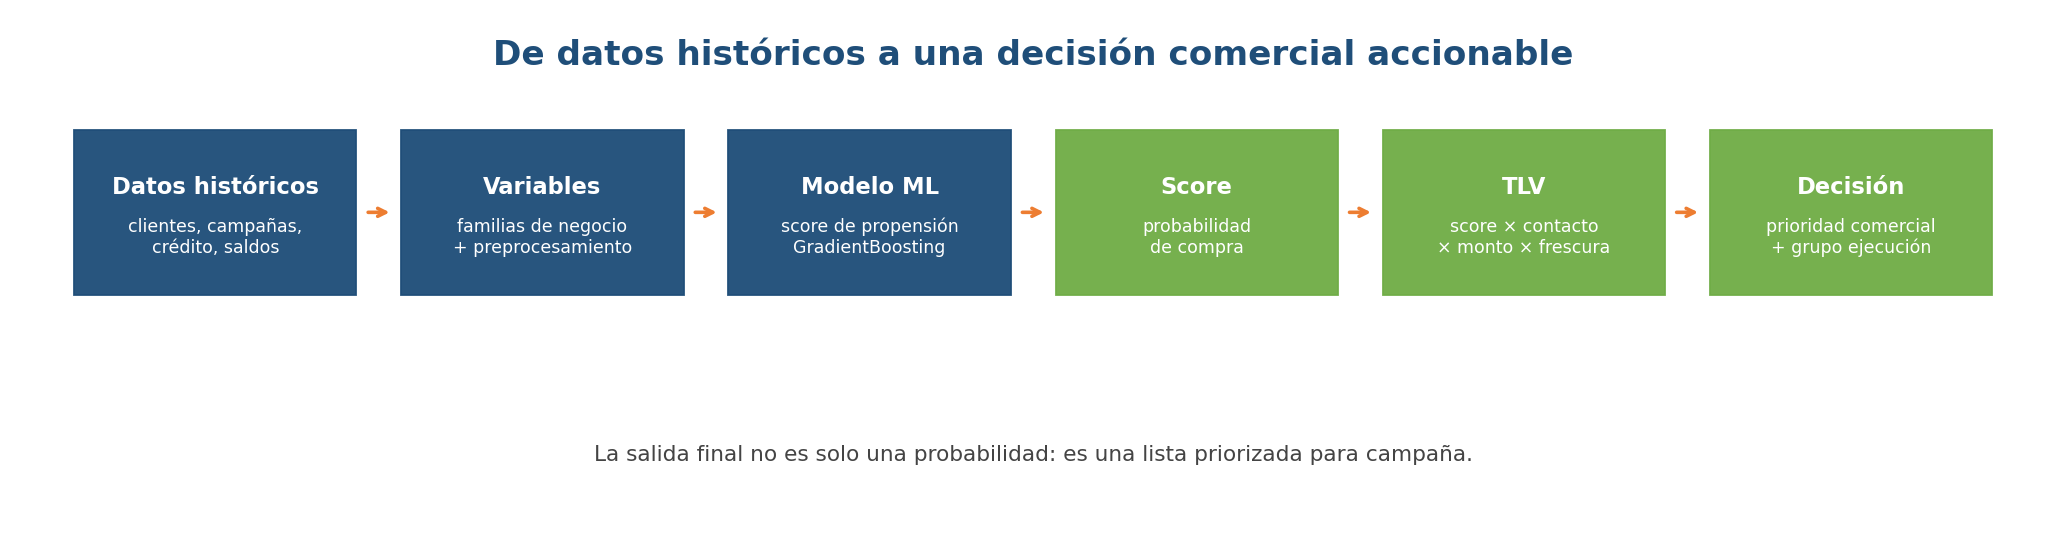


**Qué muestra:** la cadena completa del proyecto: datos → variables → modelo → score → TLV → decisión.  

**Interpretación:** el valor de negocio aparece en el postprocesamiento, porque transforma el score técnico en prioridad comercial.  

**Cómo defenderlo:** “El pipeline no se queda en predicción; entrega una lista priorizada para que negocio ejecute campañas por grupos”.


In [3]:
# ============================================================
# 2. Storyline del flujo de decisión
# ============================================================
# Corrección v7:
# - El ancho de cada caja se calcula automáticamente.
# - La última caja ya no se corta en el borde derecho.
# - El texto se mantiene centrado y legible para PPT.

fig, ax = plt.subplots(figsize=(16, 4.4))
ax.axis("off")

pasos = [
    ("Datos históricos", "clientes, campañas,\ncrédito, saldos", COLOR_AZUL),
    ("Variables", "familias de negocio\n+ preprocesamiento", COLOR_AZUL),
    ("Modelo ML", "score de propensión\nGradientBoosting", COLOR_AZUL),
    ("Score", "probabilidad\nde compra", COLOR_VERDE),
    ("TLV", "score × contacto\n× monto × frescura", COLOR_VERDE),
    ("Decisión", "prioridad comercial\n+ grupo ejecución", COLOR_VERDE),
]

n = len(pasos)
x_left, x_right = 0.03, 0.97
gap = 0.022
w = (x_right - x_left - gap * (n - 1)) / n
h = 0.31
y0 = 0.47

for i, (t, s, c) in enumerate(pasos):
    x = x_left + i * (w + gap)
    rect = plt.Rectangle((x, y0), w, h, transform=ax.transAxes, color=c, alpha=0.96)
    ax.add_patch(rect)

    ax.text(
        x + w/2, y0 + h*0.65, t,
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=12.5,
        color="white",
        fontweight="bold",
        clip_on=False
    )
    ax.text(
        x + w/2, y0 + h*0.35, s,
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=9.6,
        color="white",
        clip_on=False
    )

    if i < n - 1:
        ax.annotate(
            "",
            xy=(x + w + gap*0.82, y0 + h/2),
            xytext=(x + w + gap*0.18, y0 + h/2),
            xycoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->", lw=2.0, color=COLOR_NARANJA),
            annotation_clip=False
        )

ax.text(
    0.5, 0.92,
    "De datos históricos a una decisión comercial accionable",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=19,
    color=COLOR_AZUL,
    fontweight="bold"
)
ax.text(
    0.5, 0.17,
    "La salida final no es solo una probabilidad: es una lista priorizada para campaña.",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=12,
    color="#444444"
)

plt.tight_layout(pad=1.0)
guardar_figura("01_storyline_flujo_decision.png")
plt.show()

display(Markdown("""
**Qué muestra:** la cadena completa del proyecto: datos → variables → modelo → score → TLV → decisión.  

**Interpretación:** el valor de negocio aparece en el postprocesamiento, porque transforma el score técnico en prioridad comercial.  

**Cómo defenderlo:** “El pipeline no se queda en predicción; entrega una lista priorizada para que negocio ejecute campañas por grupos”.
"""))

## 3. Data usada en el experimento

Esta sección reconstruye desde los logs:

- periodos cargados,
- filas por periodo,
- filas de Train, Validación y OOT,
- qué corrida fue la más completa.

Esto ayuda a defender si el profesor pregunta: “¿Con cuánta data entrenaste?”.

Tabla guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling\01_periodos_usados_experimento.csv
Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\02_data_periodos_usados.png


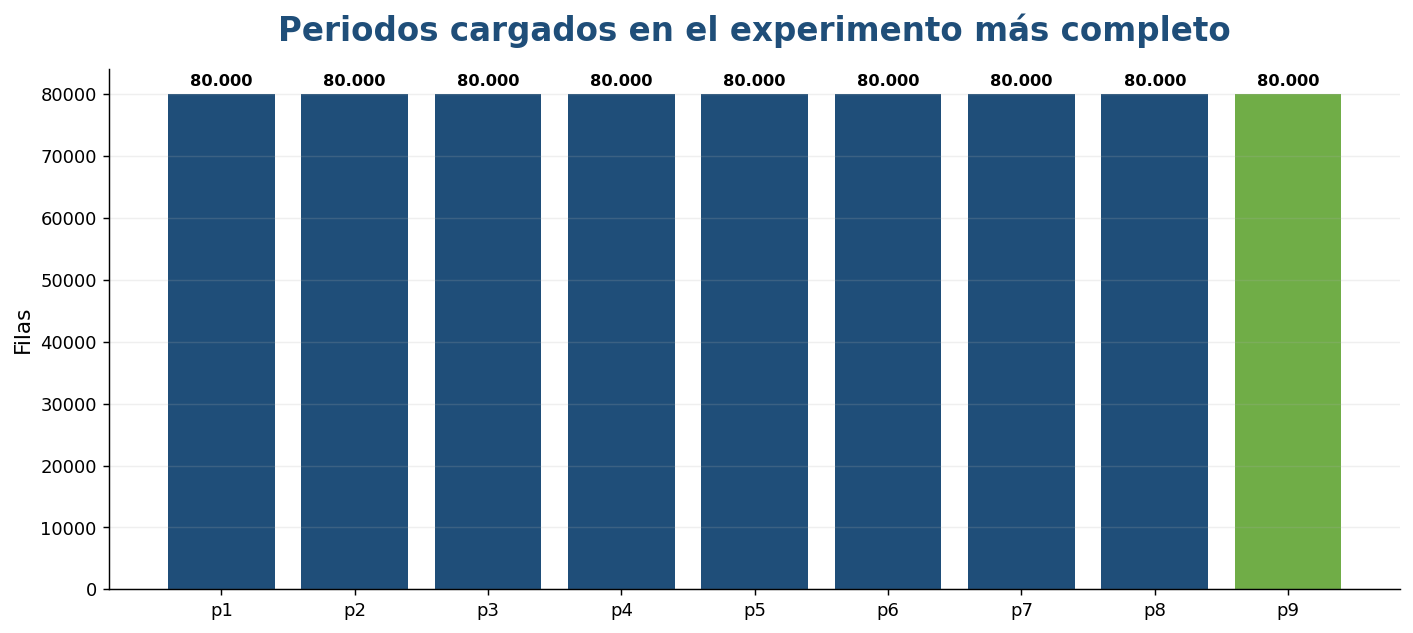


**Qué muestra:** los periodos usados según el log más completo detectado: `training_2026-05-29_21-00-45.log`.  

**Interpretación:** permite evidenciar trazabilidad de ingesta y tamaño de datos por periodo.  


Tabla guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling\02_train_valid_oot_experimento.csv
Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\03_data_train_valid_oot.png


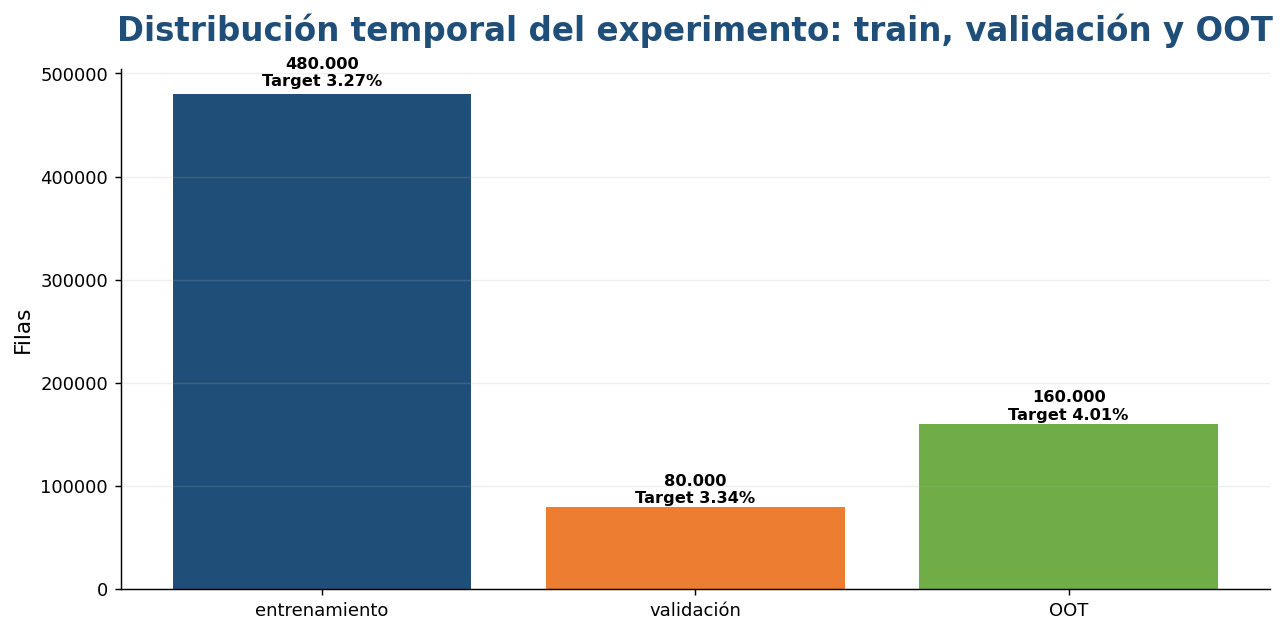


**Qué muestra:** cómo se separó la data para entrenamiento, validación y prueba fuera de tiempo.  

**Interpretación:** OOT permite simular estabilidad temporal; no se evalúa solo con una partición aleatoria.  


In [4]:
# ============================================================
# 3. Data usada en el experimento
# ============================================================

def leer_logs():
    if not DIR_LOGS.exists():
        return []
    return sorted(DIR_LOGS.glob("*.log"))

def extraer_data_logs():
    registros_periodo = []
    registros_split = []

    for log_path in leer_logs():
        texto = log_path.read_text(encoding="utf-8", errors="ignore")
        nombre = log_path.name

        for per, filas, cols in re.findall(r"Periodo\s+(\d+)\s+cargado:\s+\((\d+),\s*(\d+)\)", texto):
            registros_periodo.append({
                "log": nombre,
                "periodo": f"p{per}",
                "filas": int(filas),
                "columnas": int(cols)
            })

        for split, filas, cols, tasa in re.findall(r"(Train|Valid|OOT)\s*:\s*\((\d+),\s*(\d+)\)\s*\|\s*tasa target\s*([\d\.]+)", texto):
            registros_split.append({
                "log": nombre,
                "conjunto": {"Train": "entrenamiento", "Valid": "validación", "OOT": "OOT"}[split],
                "filas": int(filas),
                "columnas_modelo": int(cols),
                "tasa_target": float(tasa)
            })

    return pd.DataFrame(registros_periodo), pd.DataFrame(registros_split)

df_periodos, df_splits = extraer_data_logs()

if not df_periodos.empty:
    total_por_log = df_periodos.groupby("log", as_index=False)["filas"].sum().sort_values("filas", ascending=False)
    log_completo = total_por_log.iloc[0]["log"]
    periodos_exp = df_periodos[df_periodos["log"] == log_completo].copy()
    guardar_tabla(periodos_exp, "01_periodos_usados_experimento.csv")

    fig, ax = plt.subplots(figsize=(11, 5))
    colors = [COLOR_AZUL if i < len(periodos_exp)-1 else COLOR_VERDE for i in range(len(periodos_exp))]
    bars = ax.bar(periodos_exp["periodo"], periodos_exp["filas"], color=colors)
    titulo(ax, "Periodos cargados en el experimento más completo")
    ax.set_ylabel("Filas")
    ax.grid(axis="y", alpha=0.20)

    for b in bars:
        v = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, v*1.01, f"{int(v):,}".replace(",", "."),
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    plt.tight_layout()
    guardar_figura("02_data_periodos_usados.png")
    plt.show()

    display(Markdown(f"""
**Qué muestra:** los periodos usados según el log más completo detectado: `{log_completo}`.  

**Interpretación:** permite evidenciar trazabilidad de ingesta y tamaño de datos por periodo.  
"""))
else:
    display(Markdown("No se encontraron periodos cargados en logs."))

if not df_splits.empty:
    split_totales = df_splits.groupby(["log", "conjunto"], as_index=False).agg(
        filas=("filas", "max"),
        columnas_modelo=("columnas_modelo", "max"),
        tasa_target=("tasa_target", "mean")
    )
    log_split = split_totales.groupby("log")["filas"].sum().sort_values(ascending=False).index[0]
    split_exp = split_totales[split_totales["log"] == log_split].copy()

    orden = ["entrenamiento", "validación", "OOT"]
    split_exp["conjunto"] = pd.Categorical(split_exp["conjunto"], categories=orden, ordered=True)
    split_exp = split_exp.sort_values("conjunto")
    guardar_tabla(split_exp, "02_train_valid_oot_experimento.csv")

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(split_exp["conjunto"].astype(str), split_exp["filas"],
                  color=[COLOR_AZUL, COLOR_NARANJA, COLOR_VERDE][:len(split_exp)])
    titulo(ax, "Distribución temporal del experimento: train, validación y OOT")
    ax.set_ylabel("Filas")
    ax.grid(axis="y", alpha=0.20)

    for b, tasa in zip(bars, split_exp["tasa_target"]):
        v = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, v*1.01,
                f"{int(v):,}\nTarget {tasa:.2%}".replace(",", "."),
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    plt.tight_layout()
    guardar_figura("03_data_train_valid_oot.png")
    plt.show()

    display(Markdown("""
**Qué muestra:** cómo se separó la data para entrenamiento, validación y prueba fuera de tiempo.  

**Interpretación:** OOT permite simular estabilidad temporal; no se evalúa solo con una partición aleatoria.  
"""))
else:
    display(Markdown("No se encontraron splits Train/Valid/OOT en logs."))

## 4. Familias de variables y cantidad de variables

Esta sección lee `src/variables.py` para explicar la data con lenguaje de negocio.

Tabla guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling\03_variables_por_familia.csv
Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\04_variables_por_familia.png


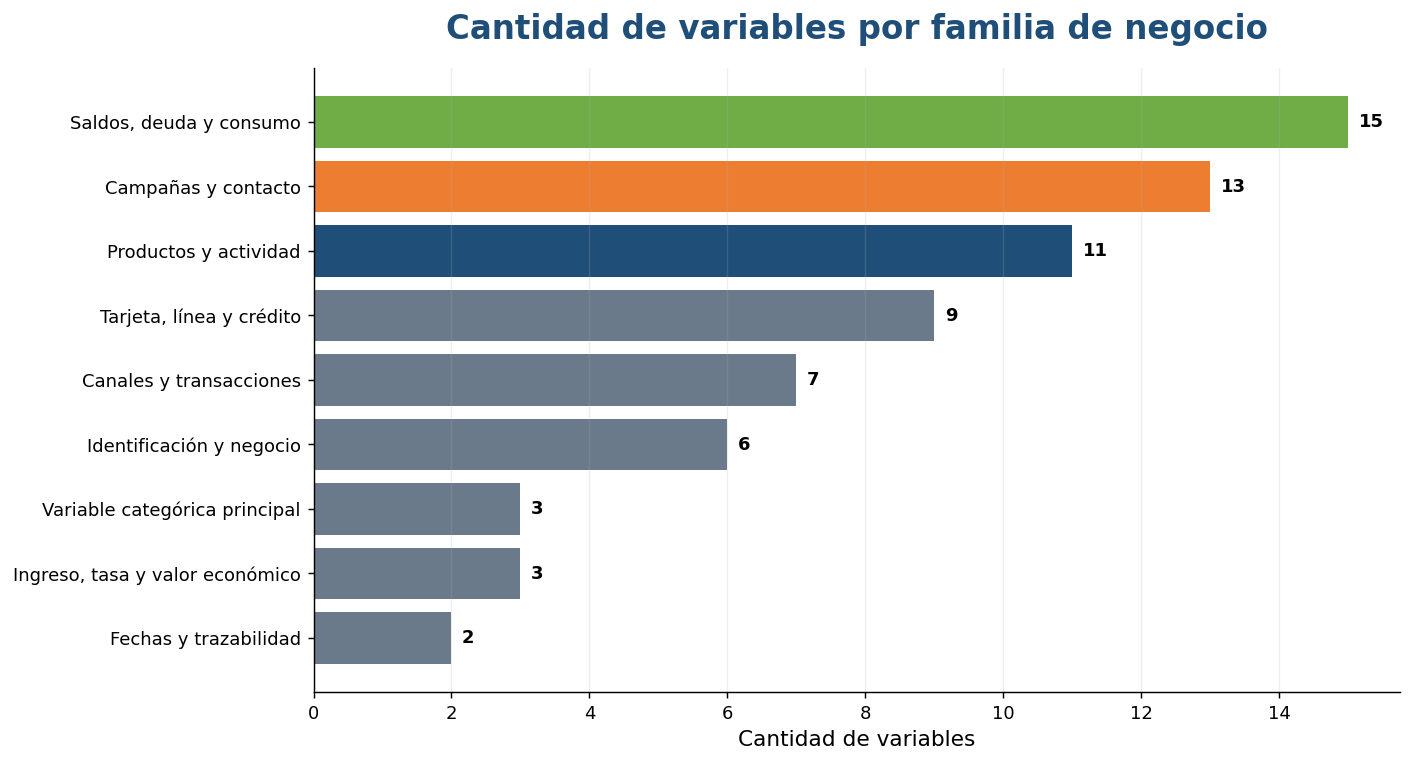


**Qué muestra:** cantidad de variables por familia según `src/variables.py`.  

**Interpretación:** el modelo se alimenta de varias dimensiones del cliente: relación bancaria, saldos, campañas, uso de productos, crédito y canales.  

**Dato para defender:** se detectaron **69 variables agrupadas en 9 familias**.


In [5]:
# ============================================================
# 4. Variables por familia desde src/variables.py
# ============================================================

def cargar_variables_py():
    path = DIR_SRC / "variables.py"
    if not path.exists():
        return {}, []
    texto = path.read_text(encoding="utf-8", errors="ignore")

    ns = {}
    try:
        exec(compile(texto, str(path), "exec"), {}, ns)
    except Exception as e:
        print(f"No se pudo ejecutar src/variables.py: {e}")
        ns = {}

    diccionario = ns.get("DICCIONARIO_GRUPOS_VARIABLES", {})
    features = ns.get("FEATURES_MODELO", []) or ns.get("VARIABLES_MODELO", []) or []
    return diccionario, features

dic_familias, features_modelo = cargar_variables_py()

if dic_familias:
    filas = []
    for familia, variables in dic_familias.items():
        variables = list(variables) if isinstance(variables, (list, tuple, set)) else []
        filas.append({
            "familia": str(familia),
            "cantidad_variables": len(variables),
            "ejemplos": ", ".join(list(variables)[:4])
        })
    df_familias = pd.DataFrame(filas).sort_values("cantidad_variables", ascending=True)
    guardar_tabla(df_familias.sort_values("cantidad_variables", ascending=False), "03_variables_por_familia.csv")

    fig, ax = plt.subplots(figsize=(11, 6))
    colors = [COLOR_GRIS_OSCURO] * len(df_familias)
    if len(colors) >= 3:
        colors[-1] = COLOR_VERDE
        colors[-2] = COLOR_NARANJA
        colors[-3] = COLOR_AZUL

    bars = ax.barh(df_familias["familia"], df_familias["cantidad_variables"], color=colors)
    titulo(ax, "Cantidad de variables por familia de negocio")
    ax.set_xlabel("Cantidad de variables")
    ax.grid(axis="x", alpha=0.20)

    for b in bars:
        v = b.get_width()
        ax.text(v + 0.15, b.get_y() + b.get_height()/2, f"{int(v)}",
                va="center", fontsize=10, fontweight="bold")

    plt.tight_layout()
    guardar_figura("04_variables_por_familia.png")
    plt.show()

    display(Markdown(f"""
**Qué muestra:** cantidad de variables por familia según `src/variables.py`.  

**Interpretación:** el modelo se alimenta de varias dimensiones del cliente: relación bancaria, saldos, campañas, uso de productos, crédito y canales.  

**Dato para defender:** se detectaron **{sum(df_familias['cantidad_variables'])} variables agrupadas en {len(df_familias)} familias**.
"""))
else:
    display(Markdown("No se encontró `DICCIONARIO_GRUPOS_VARIABLES` en `src/variables.py`."))

## 5. Variable objetivo desbalanceada

La compra/aceptación es minoritaria. Por eso la evaluación no debe depender solo de accuracy ni de un umbral 0.50.

In [6]:
# ============================================================
# 5. Target desbalanceado
# ============================================================

def encontrar_csv_original_para_scores():
    if scores is None:
        return None

    posibles_periodos = []
    if "partition" in scores.columns:
        vals = scores["partition"].dropna().astype(str).unique().tolist()
        posibles_periodos.extend(vals)

    if not posibles_periodos and scores_path:
        m = re.search(r"scores[_\-]?(\d+)", scores_path.name)
        if m:
            posibles_periodos.append(f"p{m.group(1)}")

    patrones = []
    for per in posibles_periodos:
        per = str(per).lower().replace("_extrac", "")
        patrones += [
            f"data/raw/**/{per}_extrac.csv",
            f"data/**/{per}_extrac.csv",
            f"**/{per}_extrac.csv",
        ]

    patrones += ["data/raw/**/*.csv", "data/**/*.csv"]
    return archivo_mas_reciente(patrones, base=PROJECT_ROOT)

csv_original_path = encontrar_csv_original_para_scores()
df_original = leer_csv_seguro(csv_original_path) if csv_original_path else None

if df_original is not None and "target" in df_original.columns:
    target_counts = df_original["target"].value_counts(dropna=False).sort_index()
    total = target_counts.sum()
    pct_no = target_counts.get(0, 0) / total
    pct_si = target_counts.get(1, 0) / total

    target_res = pd.DataFrame({
        "clase": ["No compra", "Compra"],
        "cantidad": [target_counts.get(0, 0), target_counts.get(1, 0)],
        "participacion": [pct_no, pct_si]
    })
    guardar_tabla(target_res, "04_target_desbalanceado.csv")

    fig, ax = plt.subplots(figsize=(10, 5.5))
    bars = ax.bar(target_res["clase"], target_res["participacion"], color=[COLOR_AZUL, COLOR_NARANJA])
    titulo(ax, "Variable objetivo desbalanceada")
    ax.set_ylabel("Participación")
    ax.set_ylim(0, min(1.16, max(target_res["participacion"]) * 1.22))
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    ax.grid(axis="y", alpha=0.20)

    for b, cant, pct in zip(bars, target_res["cantidad"], target_res["participacion"]):
        ax.text(
            b.get_x() + b.get_width()/2,
            b.get_height() + 0.030,
            f"{pct:.1%}\n({int(cant):,})".replace(",", "."),
            ha="center",
            va="bottom",
            fontsize=13,
            fontweight="bold"
        )

    plt.tight_layout()
    guardar_figura("05_target_desbalanceado.png")
    plt.show()

    display(Markdown("""
**Qué muestra:** la clase positiva es minoritaria.  

**Interpretación:** con una tasa baja de compra, accuracy puede ser engañosa. Por eso se priorizan AUC, estabilidad OOT, deciles, lift y ganancia acumulada.  

**Cómo defenderlo:** “El modelo debe ordenar la cartera y concentrar compradores, no solo acertar la clase mayoritaria”.
"""))
else:
    display(Markdown("No se encontró `target` en el CSV original. Se omite evaluación offline con target."))

No se encontró `target` en el CSV original. Se omite evaluación offline con target.

## 6. Comparación de modelos y estabilidad OOT

El campeón debe tener buen AUC y estabilidad temporal.  
El OOT permite revisar si el modelo se degrada en periodos futuros.

Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\06_modelos_auc_test_oot.png


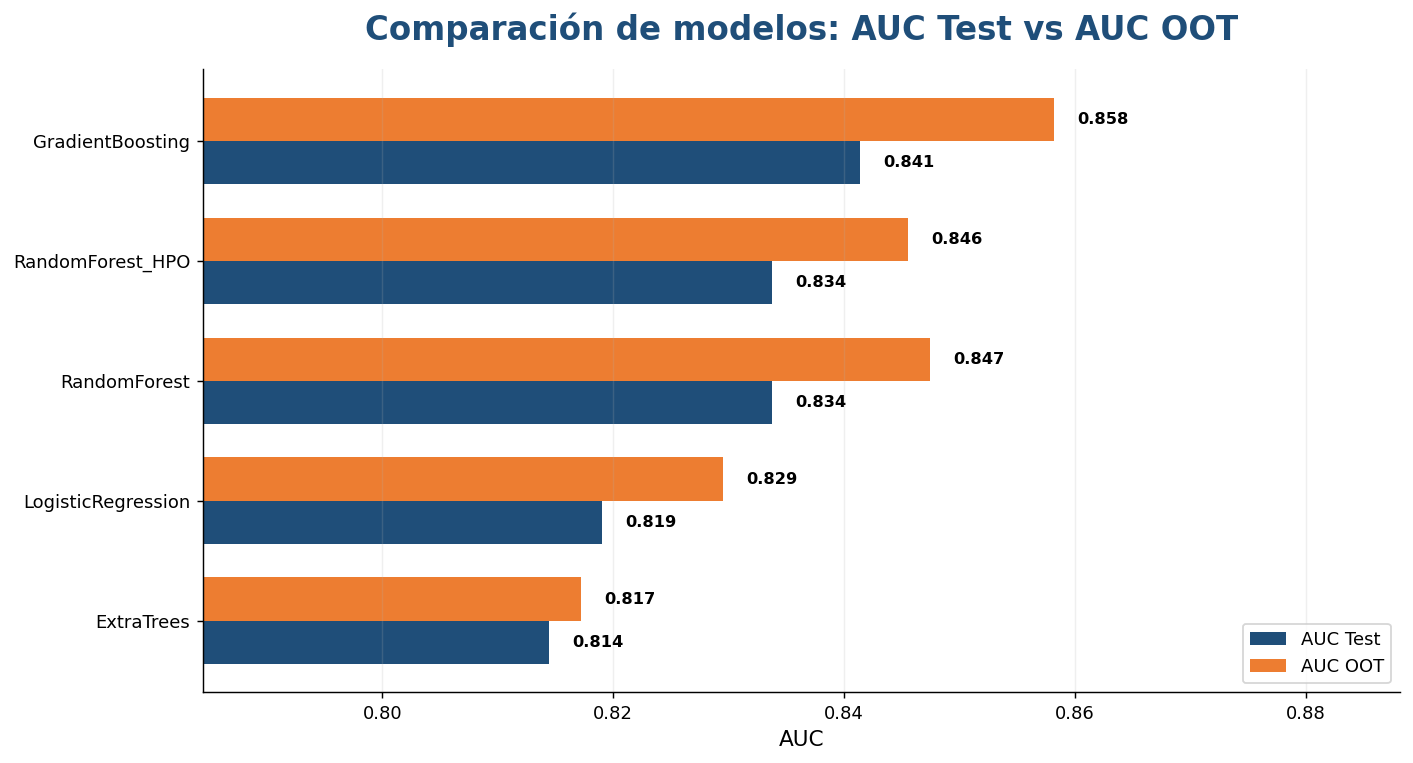


**Qué muestra:** compara rendimiento en validación y en OOT.  

**Interpretación:** un buen modelo no solo tiene buen AUC en validación, también mantiene desempeño en OOT.  

**Cómo defenderlo:** “Seleccioné el campeón considerando performance y estabilidad temporal”.


In [7]:
# ============================================================
# 6. Comparación de modelos: AUC Test vs AUC OOT
# ============================================================

def normalizar_leaderboard(df):
    if df is None:
        return None
    lb = df.copy()
    lb.columns = [c.strip() for c in lb.columns]
    rename_map = {}
    for c in lb.columns:
        cl = c.lower()
        if cl in ["modelo", "model", "nombre_modelo"]:
            rename_map[c] = "modelo"
        elif cl in ["auc_test", "auc_valid", "auc_validacion"]:
            rename_map[c] = "auc_test"
        elif cl in ["auc_oot", "oot_auc"]:
            rename_map[c] = "auc_oot"
        elif cl in ["gap", "auc_gap", "gap_oot"]:
            rename_map[c] = "gap"
    lb = lb.rename(columns=rename_map)
    if "gap" not in lb.columns and {"auc_test", "auc_oot"}.issubset(lb.columns):
        lb["gap"] = (lb["auc_test"] - lb["auc_oot"]).abs()
    return lb

lb = normalizar_leaderboard(leaderboard)

if lb is not None and {"modelo", "auc_test", "auc_oot"}.issubset(lb.columns):
    lb_plot = lb.sort_values("auc_test", ascending=True)

    fig, ax = plt.subplots(figsize=(11, 6))
    y = np.arange(len(lb_plot))
    h = 0.36
    ax.barh(y - h/2, lb_plot["auc_test"], height=h, color=COLOR_AZUL, label="AUC Test")
    ax.barh(y + h/2, lb_plot["auc_oot"], height=h, color=COLOR_NARANJA, label="AUC OOT")

    ax.set_yticks(y)
    ax.set_yticklabels(lb_plot["modelo"])
    titulo(ax, "Comparación de modelos: AUC Test vs AUC OOT")
    ax.set_xlabel("AUC")
    xmin = max(0, min(lb_plot["auc_test"].min(), lb_plot["auc_oot"].min()) - 0.03)
    xmax = min(1, max(lb_plot["auc_test"].max(), lb_plot["auc_oot"].max()) + 0.03)
    ax.set_xlim(xmin, xmax)
    ax.grid(axis="x", alpha=0.20)
    ax.legend(loc="lower right")

    for yi, a, b in zip(y, lb_plot["auc_test"], lb_plot["auc_oot"]):
        ax.text(a + 0.002, yi - h/2, f"{a:.3f}", va="center", fontsize=9, fontweight="bold")
        ax.text(b + 0.002, yi + h/2, f"{b:.3f}", va="center", fontsize=9, fontweight="bold")

    plt.tight_layout()
    guardar_figura("06_modelos_auc_test_oot.png")
    plt.show()

    display(Markdown("""
**Qué muestra:** compara rendimiento en validación y en OOT.  

**Interpretación:** un buen modelo no solo tiene buen AUC en validación, también mantiene desempeño en OOT.  

**Cómo defenderlo:** “Seleccioné el campeón considerando performance y estabilidad temporal”.
"""))
else:
    display(Markdown("No se encontró leaderboard con columnas de AUC Test/OOT."))

Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\07_gap_estabilidad_oot.png


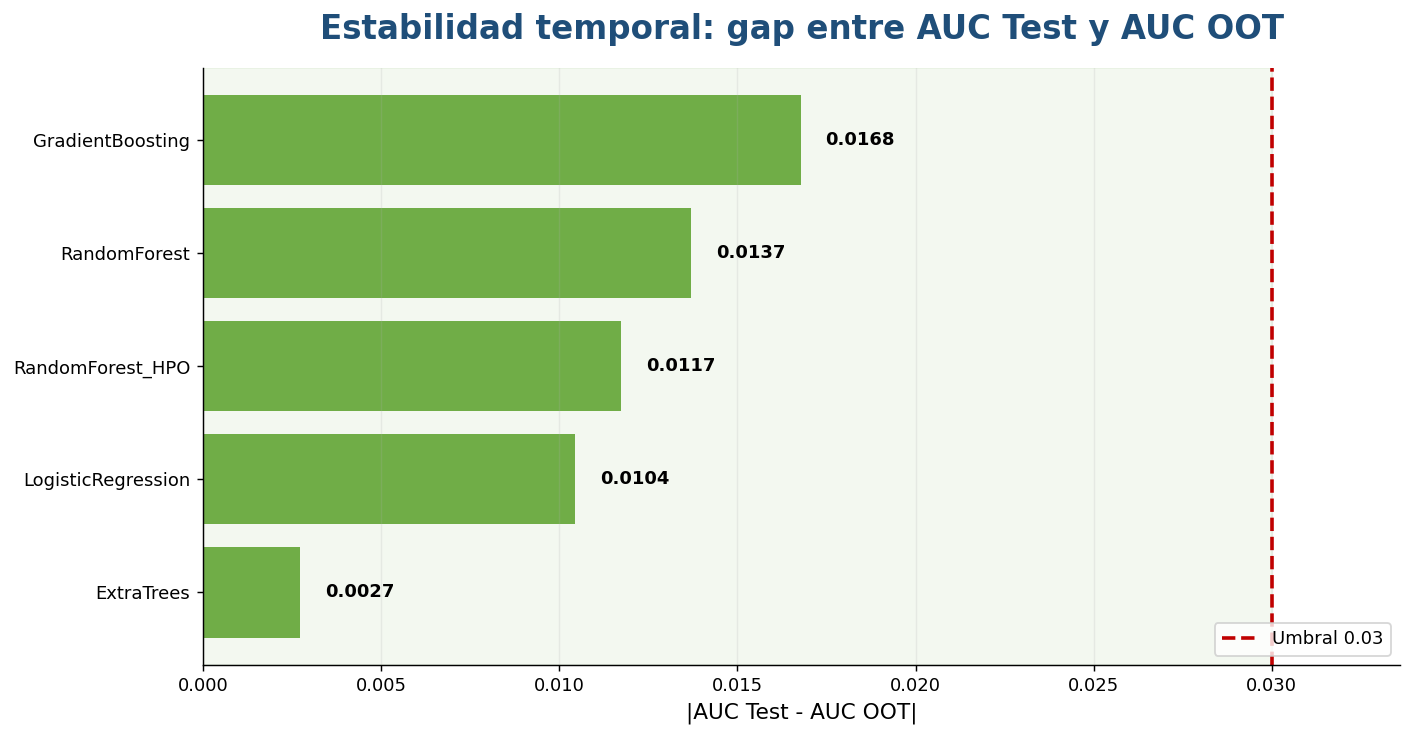


**Qué muestra:** el gap entre validación y OOT.  

**Interpretación:** menor gap implica menor degradación temporal. Un modelo estable es más defendible para producción.  

**Cómo defenderlo:** “No elegí solo el AUC más alto; también revisé que el modelo no se degrade fuera de tiempo”.


In [8]:
# ============================================================
# 7. Gap de estabilidad temporal
# ============================================================

if lb is not None and {"modelo", "gap"}.issubset(lb.columns):
    umbral_gap = 0.03
    gap_plot = lb.sort_values("gap", ascending=True)

    fig, ax = plt.subplots(figsize=(11, 5.8))
    colors = [COLOR_VERDE if g <= umbral_gap else COLOR_NARANJA for g in gap_plot["gap"]]
    bars = ax.barh(gap_plot["modelo"], gap_plot["gap"], color=colors)
    titulo(ax, "Estabilidad temporal: gap entre AUC Test y AUC OOT")
    ax.set_xlabel("|AUC Test - AUC OOT|")
    ax.axvline(umbral_gap, color=COLOR_ROJO, linestyle="--", lw=2, label=f"Umbral {umbral_gap:.2f}")
    ax.axvspan(0, umbral_gap, color=COLOR_VERDE, alpha=0.08)
    ax.grid(axis="x", alpha=0.20)
    ax.legend(loc="lower right")

    for b in bars:
        v = b.get_width()
        ax.text(v + 0.0007, b.get_y() + b.get_height()/2, f"{v:.4f}",
                va="center", fontsize=10, fontweight="bold")

    ax.set_xlim(0, max(umbral_gap * 1.12, gap_plot["gap"].max() * 1.18))
    plt.tight_layout()
    guardar_figura("07_gap_estabilidad_oot.png")
    plt.show()

    display(Markdown("""
**Qué muestra:** el gap entre validación y OOT.  

**Interpretación:** menor gap implica menor degradación temporal. Un modelo estable es más defendible para producción.  

**Cómo defenderlo:** “No elegí solo el AUC más alto; también revisé que el modelo no se degrade fuera de tiempo”.
"""))
else:
    display(Markdown("No hay columnas suficientes para calcular gap."))

## 7. Importancia predictiva por familias

La importancia por familia permite explicar el modelo sin depender de nombres técnicos de columnas.  
No implica causalidad; indica aporte predictivo dentro del modelo.

Tabla guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling\05_importancia_familias_storytelling.csv
Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\08_importancia_por_familia_negocio.png


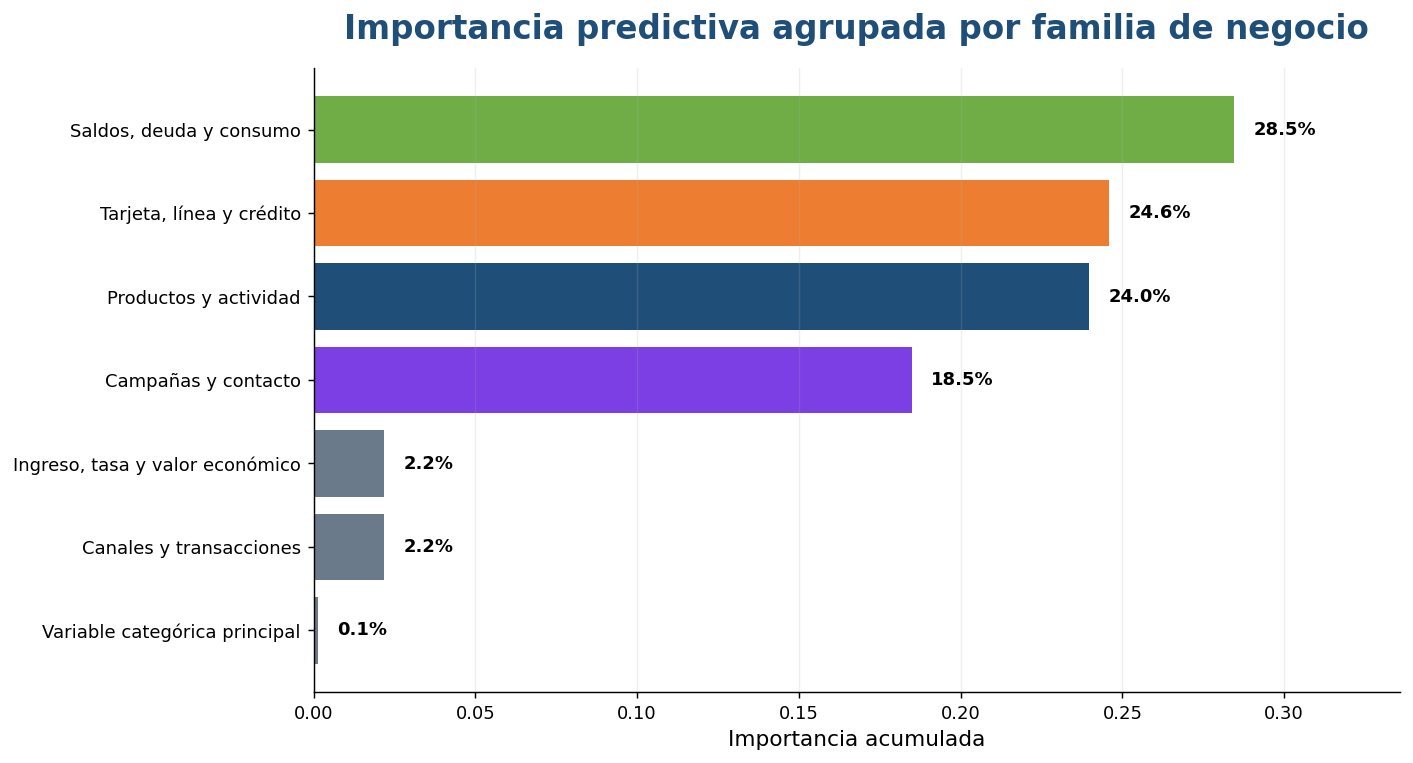


**Qué muestra:** qué familias de variables aportan más al score.  

**Interpretación:** la explicación principal del modelo debe hacerse por familias de negocio, no solo por nombres técnicos.  

**Cuidado técnico:** importancia no significa causalidad; significa aporte predictivo para ordenar clientes.


In [9]:
# ============================================================
# 8. Importancia por familia de negocio
# ============================================================

def normalizar_importancia_familias(df):
    if df is None:
        return None
    tmp = df.copy()
    rename = {}
    for c in tmp.columns:
        cl = c.lower()
        if "familia" in cl or "grupo" in cl:
            rename[c] = "familia"
        elif "import" in cl or "peso" in cl:
            rename[c] = "importancia"
    tmp = tmp.rename(columns=rename)
    if not {"familia", "importancia"}.issubset(tmp.columns):
        return None
    tmp = tmp[["familia", "importancia"]].dropna()
    total = tmp["importancia"].sum()
    if total > 0 and total > 1.5:
        tmp["importancia"] = tmp["importancia"] / total
    return tmp.sort_values("importancia", ascending=True)

imp_fam = normalizar_importancia_familias(importancia_familias)

if imp_fam is None and importancia_vars is not None and dic_familias:
    tmp = importancia_vars.copy()
    rename = {}
    for c in tmp.columns:
        cl = c.lower()
        if cl in ["variable", "feature", "columna"]:
            rename[c] = "variable"
        elif "import" in cl or "peso" in cl:
            rename[c] = "importancia"
    tmp = tmp.rename(columns=rename)
    if {"variable", "importancia"}.issubset(tmp.columns):
        mapa = {}
        for fam, vars_ in dic_familias.items():
            for v in vars_:
                mapa[v] = fam
        tmp["familia"] = tmp["variable"].map(mapa).fillna("Otra")
        imp_fam = tmp.groupby("familia", as_index=False)["importancia"].sum()
        total = imp_fam["importancia"].sum()
        if total > 0:
            imp_fam["importancia"] = imp_fam["importancia"] / total
        imp_fam = imp_fam.sort_values("importancia", ascending=True)

if imp_fam is not None and not imp_fam.empty:
    guardar_tabla(imp_fam.sort_values("importancia", ascending=False), "05_importancia_familias_storytelling.csv")

    fig, ax = plt.subplots(figsize=(11, 6))
    colors = [COLOR_GRIS_OSCURO] * len(imp_fam)
    if len(colors) >= 4:
        colors[-1] = COLOR_VERDE
        colors[-2] = COLOR_NARANJA
        colors[-3] = COLOR_AZUL
        colors[-4] = COLOR_MORADO

    bars = ax.barh(imp_fam["familia"], imp_fam["importancia"], color=colors)
    titulo(ax, "Importancia predictiva agrupada por familia de negocio")
    ax.set_xlabel("Importancia acumulada")
    ax.grid(axis="x", alpha=0.20)

    for b, v in zip(bars, imp_fam["importancia"]):
        ax.text(v + 0.006, b.get_y() + b.get_height()/2,
                f"{v:.1%}", va="center", fontsize=10, fontweight="bold")

    ax.set_xlim(0, max(imp_fam["importancia"].max() * 1.18, 0.1))
    plt.tight_layout()
    guardar_figura("08_importancia_por_familia_negocio.png")
    plt.show()

    display(Markdown("""
**Qué muestra:** qué familias de variables aportan más al score.  

**Interpretación:** la explicación principal del modelo debe hacerse por familias de negocio, no solo por nombres técnicos.  

**Cuidado técnico:** importancia no significa causalidad; significa aporte predictivo para ordenar clientes.
"""))
else:
    display(Markdown("No se encontró importancia por familia ni se pudo reconstruir."))

## 8. Deciles de score y evaluación offline con target

Los deciles ordenan clientes por score:

- D1 = 10% con mayor score,
- D10 = 10% con menor score.

Si el modelo ordena bien, D1 debe concentrar más compradores reales que D10.

Tabla guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling\06_score_promedio_por_decil.csv
Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\09_score_promedio_por_decil.png


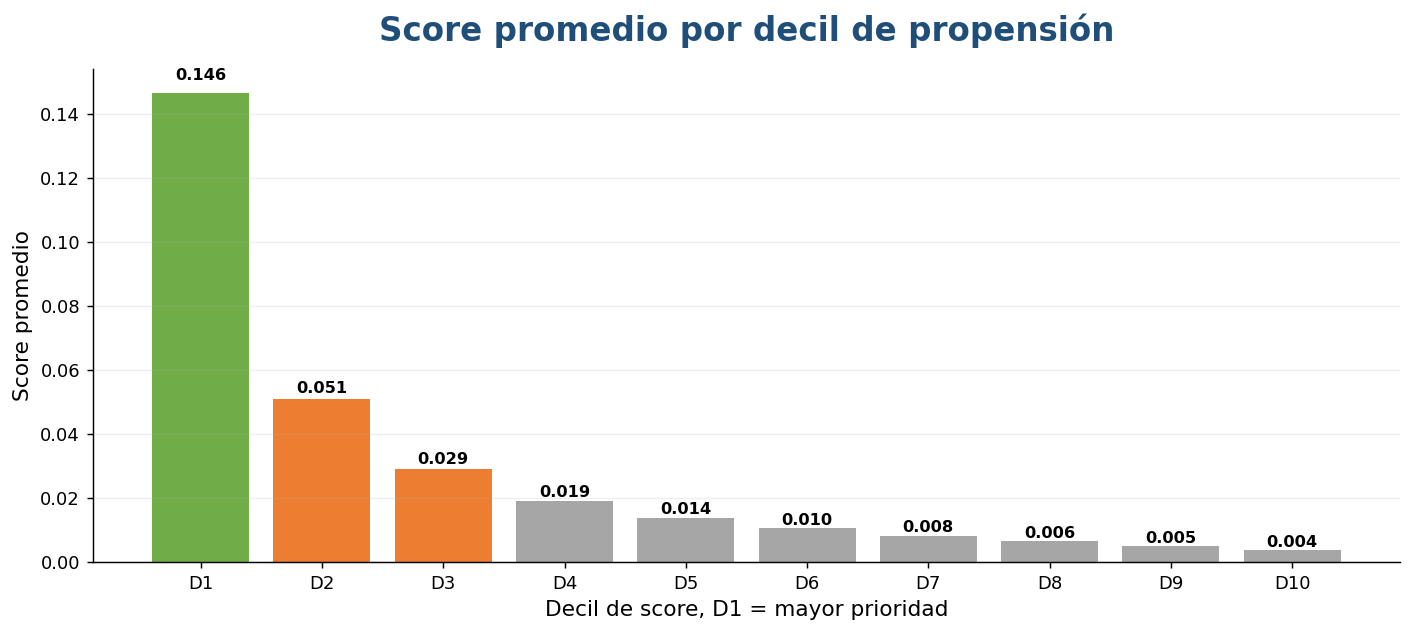


**Qué muestra:** el score promedio cae desde D1 hacia D10.  

**Interpretación:** el modelo ordena la cartera: D1 concentra los clientes con mayor propensión estimada.  

**Cómo defenderlo:** “Antes de hablar de compra real, verifico que el score genere un ranking operativo”.


In [10]:
# ============================================================
# 9. Construcción de deciles y cruce con target histórico
# ============================================================

def detectar_columna_score(df):
    if df is None:
        return None
    candidatos = [
        "probabilidad_modelo", "score", "score_modelo", "prob_value_contact",
        "probabilidad", "prediction_score", "proba"
    ]
    for c in candidatos:
        if c in df.columns:
            return c
    for c in df.columns:
        cl = c.lower()
        if any(x in cl for x in ["prob", "score"]) and pd.api.types.is_numeric_dtype(df[c]):
            return c
    return None

def detectar_columna_tlv(df):
    if df is None:
        return None
    candidatos = ["tlv", "puntuacion_tlv", "score_tlv", "tlv_score"]
    for c in candidatos:
        if c in df.columns:
            return c
    for c in df.columns:
        if "tlv" in c.lower() and pd.api.types.is_numeric_dtype(df[c]):
            return c
    return None

def detectar_columna_grupo(df):
    if df is None:
        return None
    candidatos = ["grupo_ejecucion", "grupo", "grupo_prioridad", "decile", "decil"]
    for c in candidatos:
        if c in df.columns:
            return c
    for c in df.columns:
        cl = c.lower()
        if "grupo" in cl or "ejec" in cl:
            return c
    return None

def cruzar_scores_target(scores, original):
    if scores is None or original is None or "target" not in original.columns:
        return None

    claves = ["key_value", "codunicocli"]
    for clave in claves:
        if clave in scores.columns and clave in original.columns:
            base = scores.copy()
            ori = original[[clave, "target"]].drop_duplicates(subset=[clave]).copy()
            out = base.merge(ori, on=clave, how="left")
            if out["target"].notna().sum() > 0:
                return out

    if len(scores) == len(original):
        out = scores.copy()
        out["target"] = original["target"].values
        return out

    return None

score_col = detectar_columna_score(scores)
tlv_col = detectar_columna_tlv(scores)
grupo_col = detectar_columna_grupo(scores)

df_eval = cruzar_scores_target(scores, df_original)

if scores is not None and score_col:
    dec = scores.copy()
    dec[score_col] = pd.to_numeric(dec[score_col], errors="coerce")
    dec = dec.dropna(subset=[score_col]).copy()
    dec["decil"] = pd.qcut(dec[score_col].rank(method="first", ascending=False), 10, labels=[f"D{i}" for i in range(1, 11)])

    score_decil = dec.groupby("decil", as_index=False).agg(
        score_promedio=(score_col, "mean"),
        clientes=(score_col, "count")
    )
    score_decil["orden"] = score_decil["decil"].str.extract(r"(\d+)").astype(int)
    score_decil = score_decil.sort_values("orden")
    guardar_tabla(score_decil, "06_score_promedio_por_decil.csv")

    fig, ax = plt.subplots(figsize=(11, 5))
    colors = [COLOR_VERDE, COLOR_NARANJA, COLOR_NARANJA] + [COLOR_GRIS] * 7
    bars = ax.bar(score_decil["decil"], score_decil["score_promedio"], color=colors[:len(score_decil)])
    titulo(ax, "Score promedio por decil de propensión")
    ax.set_xlabel("Decil de score, D1 = mayor prioridad")
    ax.set_ylabel("Score promedio")
    ax.grid(axis="y", alpha=0.20)

    for b, v in zip(bars, score_decil["score_promedio"]):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.02, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    plt.tight_layout()
    guardar_figura("09_score_promedio_por_decil.png")
    plt.show()

    display(Markdown("""
**Qué muestra:** el score promedio cae desde D1 hacia D10.  

**Interpretación:** el modelo ordena la cartera: D1 concentra los clientes con mayor propensión estimada.  

**Cómo defenderlo:** “Antes de hablar de compra real, verifico que el score genere un ranking operativo”.
"""))
else:
    display(Markdown("No se encontró columna de score en scores."))

In [11]:
# ============================================================
# 10. Tasa real de compra, lift y ganancia acumulada
# ============================================================

if df_eval is not None and score_col and "target" in df_eval.columns:
    ev = df_eval.copy()
    ev[score_col] = pd.to_numeric(ev[score_col], errors="coerce")
    ev["target"] = pd.to_numeric(ev["target"], errors="coerce")
    ev = ev.dropna(subset=[score_col, "target"]).copy()
    ev["target"] = ev["target"].astype(int)
    ev["decil"] = pd.qcut(ev[score_col].rank(method="first", ascending=False), 10, labels=[f"D{i}" for i in range(1, 11)])

    tasa_general = ev["target"].mean()

    decil_eval = ev.groupby("decil", as_index=False).agg(
        clientes=("target", "count"),
        compradores=("target", "sum"),
        tasa_compra=("target", "mean"),
        score_promedio=(score_col, "mean")
    )
    decil_eval["orden"] = decil_eval["decil"].str.extract(r"(\d+)").astype(int)
    decil_eval = decil_eval.sort_values("orden")
    decil_eval["lift"] = decil_eval["tasa_compra"] / tasa_general if tasa_general > 0 else np.nan
    decil_eval["compradores_acum"] = decil_eval["compradores"].cumsum()
    decil_eval["clientes_acum"] = decil_eval["clientes"].cumsum()
    decil_eval["pct_compradores_acum"] = decil_eval["compradores_acum"] / max(decil_eval["compradores"].sum(), 1)
    decil_eval["pct_clientes_acum"] = decil_eval["clientes_acum"] / decil_eval["clientes"].sum()

    guardar_tabla(decil_eval, "07_evaluacion_offline_deciles.csv")

    fig, ax = plt.subplots(figsize=(11, 5))
    colors = [COLOR_VERDE, COLOR_NARANJA, COLOR_NARANJA] + [COLOR_GRIS] * 7
    bars = ax.bar(decil_eval["decil"], decil_eval["tasa_compra"], color=colors[:len(decil_eval)])
    titulo(ax, "Evaluación offline: tasa real de compra por decil")
    ax.set_xlabel("Decil de score, D1 = mayor prioridad")
    ax.set_ylabel("Tasa de compra")
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    ax.axhline(tasa_general, color=COLOR_ROJO, linestyle="--", lw=2, label=f"Tasa general: {tasa_general:.1%}")
    ax.grid(axis="y", alpha=0.20)
    ax.legend(loc="upper right")

    for b, v in zip(bars, decil_eval["tasa_compra"]):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f"{v:.1%}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

    plt.tight_layout()
    guardar_figura("10_tasa_compra_por_decil.png")
    plt.show()

    display(Markdown("""
**Qué muestra:** tasa real de compra por decil usando el target histórico.  

**Interpretación:** el target se usa solo después de inferir para validar offline si el ranking concentró compradores.  

**Cómo defenderlo:** “No hay fuga de información; primero genero scores y luego cruzo con target histórico para medir desempeño”.
"""))

    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(decil_eval["decil"], decil_eval["lift"], color=colors[:len(decil_eval)])
    titulo(ax, "Lift por decil: mejora frente a contactar al azar")
    ax.set_xlabel("Decil de score")
    ax.set_ylabel("Lift")
    ax.axhline(1, color=COLOR_ROJO, linestyle="--", lw=2, label="Azar = 1.0x")
    ax.grid(axis="y", alpha=0.20)
    ax.legend(loc="upper right")

    for b, v in zip(bars, decil_eval["lift"]):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.08, f"{v:.1f}x",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax.set_ylim(0, max(1.2, decil_eval["lift"].max() * 1.25))
    plt.tight_layout()
    guardar_figura("11_lift_por_decil.png")
    plt.show()

    display(Markdown("""
**Qué muestra:** cuántas veces mejor es cada decil frente a seleccionar clientes al azar.  

**Interpretación:** lift mayor que 1 significa que el decil concentra más compradores que la tasa promedio.  

**Cómo defenderlo:** “Si contacto D1, soy más eficiente que una campaña aleatoria”.
"""))

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(decil_eval["pct_clientes_acum"], decil_eval["pct_compradores_acum"],
            marker="o", lw=3, color=COLOR_VERDE, label="Modelo")
    ax.plot([0, 1], [0, 1], linestyle="--", lw=2, color=COLOR_GRIS, label="Azar")
    titulo(ax, "Ganancia acumulada: compradores capturados por contacto acumulado")
    ax.set_xlabel("Porcentaje acumulado de clientes contactados")
    ax.set_ylabel("Porcentaje acumulado de compradores capturados")
    ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")

    for _, r in decil_eval.iterrows():
        if int(r["orden"]) in [1, 2, 3, 5, 10]:
            ax.text(r["pct_clientes_acum"], r["pct_compradores_acum"] + 0.035,
                    f'{r["decil"]}\n{r["pct_compradores_acum"]:.1%}',
                    ha="center", fontsize=9, fontweight="bold")

    plt.tight_layout()
    guardar_figura("12_ganancia_acumulada_compradores.png")
    plt.show()

    display(Markdown("""
**Qué muestra:** porcentaje de compradores reales capturados al contactar los primeros deciles.  

**Interpretación:** si la curva del modelo está sobre la línea de azar, la priorización agrega valor.  

**Cómo defenderlo:** “Esto traduce el modelo a una decisión de campaña: cuánto capturo si contacto el top 10%, 20% o 30%”.
"""))
else:
    display(Markdown("No se pudo cruzar scores con target. Se omiten tasa por decil, lift y ganancia acumulada."))

No se pudo cruzar scores con target. Se omiten tasa por decil, lift y ganancia acumulada.

## 9. Evaluación de umbrales

El umbral 0.50 es una referencia técnica, pero en una base desbalanceada suele no ser el mejor.  
Se evalúan varios umbrales contra el target histórico para ver precision, recall y F1.

> Para el negocio, la decisión principal sigue siendo deciles + TLV. El umbral sirve como lectura técnica adicional.

In [12]:
# ============================================================
# 11. Evaluación de umbrales
# ============================================================

def metricas_umbral(y_true, y_score, umbral):
    pred = (y_score >= umbral).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / max(len(y_true), 1)

    return {
        "umbral": umbral,
        "contactados": int(pred.sum()),
        "tasa_contacto": float(pred.mean()),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
    }

if df_eval is not None and score_col and "target" in df_eval.columns:
    ev = df_eval.copy()
    ev[score_col] = pd.to_numeric(ev[score_col], errors="coerce")
    ev["target"] = pd.to_numeric(ev["target"], errors="coerce")
    ev = ev.dropna(subset=[score_col, "target"]).copy()
    y_true = ev["target"].astype(int).values
    y_score = ev[score_col].values

    umbrales = [0.01, 0.02, 0.03, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 0.50]
    df_umbral = pd.DataFrame([metricas_umbral(y_true, y_score, u) for u in umbrales])
    mejor = df_umbral.sort_values("f1", ascending=False).iloc[0]
    umbral_recomendado = float(mejor["umbral"])

    guardar_tabla(df_umbral, "08_evaluacion_umbrales.csv")

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(df_umbral["umbral"], df_umbral["precision"], marker="o", lw=2.2, color=COLOR_AZUL, label="Precision")
    ax.plot(df_umbral["umbral"], df_umbral["recall"], marker="o", lw=2.2, color=COLOR_NARANJA, label="Recall")
    ax.plot(df_umbral["umbral"], df_umbral["f1"], marker="o", lw=2.2, color=COLOR_VERDE, label="F1")
    ax.axvline(0.50, color=COLOR_ROJO, linestyle="--", lw=1.8, label="Umbral 0.50")
    ax.axvline(umbral_recomendado, color=COLOR_MORADO, linestyle=":", lw=2.2, label=f"Mejor F1: {umbral_recomendado:.2f}")

    titulo(ax, "Evaluación de umbrales: precision, recall y F1")
    ax.set_xlabel("Umbral")
    ax.set_ylabel("Métrica")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.20)
    ax.legend(loc="upper center", ncol=5, frameon=True)

    plt.tight_layout()
    guardar_figura("13_evaluacion_umbrales.png")
    plt.show()

    display(Markdown(f"""
**Qué muestra:** el trade-off entre precision, recall y F1 al cambiar el umbral.  

**Interpretación:** el umbral 0.50 queda como referencia clásica. Según F1, el umbral técnico sugerido es aproximadamente **{umbral_recomendado:.2f}**.  

**Cómo defenderlo:** “El modelo produce probabilidades; el umbral se decide después con datos históricos. Para negocio, complemento el umbral con deciles y TLV”.
"""))

    for u, etiqueta in [(0.50, "050"), (umbral_recomendado, "optimo_f1")]:
        m = metricas_umbral(y_true, y_score, u)
        matriz = np.array([[m["TN"], m["FP"]], [m["FN"], m["TP"]]])

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(matriz, cmap="Blues")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Pred 0", "Pred 1"])
        ax.set_yticklabels(["Real 0", "Real 1"])
        titulo(ax, f"Matriz de confusión con umbral {u:.2f}")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{matriz[i, j]:,}".replace(",", "."),
                        ha="center", va="center",
                        fontsize=16, fontweight="bold",
                        color="white" if matriz[i, j] > matriz.max()/2 else "black")
        plt.tight_layout()
        guardar_figura(f"14_matriz_confusion_umbral_{etiqueta}.png")
        plt.show()

else:
    display(Markdown("No se pudo evaluar umbrales porque falta target o score."))

No se pudo evaluar umbrales porque falta target o score.

## 10. Score, TLV y grupos de ejecución

El score mide propensión técnica.  
El TLV convierte esa propensión en valor de negocio al incluir contacto, monto y frescura.

Tabla guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling\09_score_vs_tlv_decil.csv
Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\15_score_vs_tlv_por_decil.png


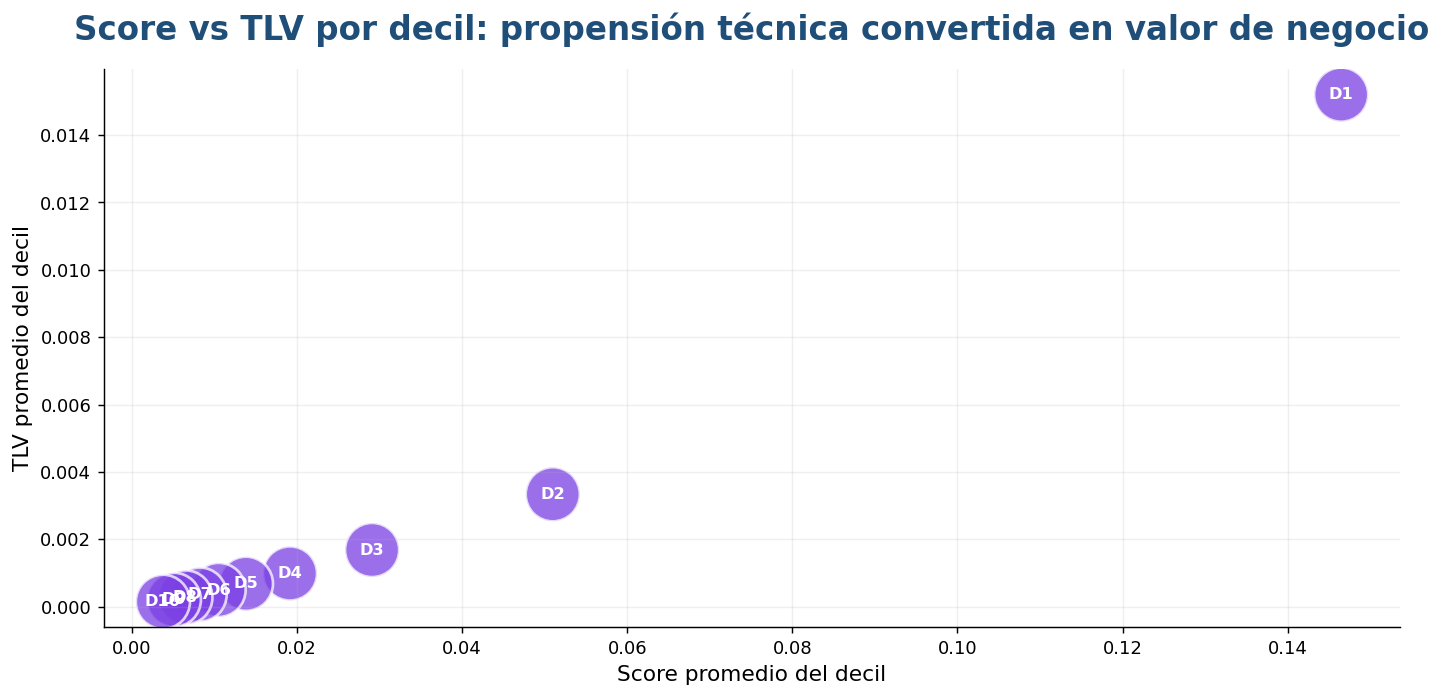


**Qué muestra:** relación entre score promedio y TLV promedio por decil.  

**Interpretación:** el TLV permite priorizar no solo por probabilidad, sino por valor comercial esperado.  

**Cómo defenderlo:** “El score ordena propensión; el TLV traduce esa propensión a una prioridad de campaña”.


In [13]:
# ============================================================
# 12. Score vs TLV por decil
# ============================================================

if scores is not None and score_col and tlv_col:
    tmp = scores.copy()
    tmp[score_col] = pd.to_numeric(tmp[score_col], errors="coerce")
    tmp[tlv_col] = pd.to_numeric(tmp[tlv_col], errors="coerce")
    tmp = tmp.dropna(subset=[score_col, tlv_col]).copy()
    tmp["decil"] = pd.qcut(tmp[score_col].rank(method="first", ascending=False), 10, labels=[f"D{i}" for i in range(1, 11)])

    res = tmp.groupby("decil", as_index=False).agg(
        score_promedio=(score_col, "mean"),
        tlv_promedio=(tlv_col, "mean"),
        clientes=(score_col, "count")
    )
    res["orden"] = res["decil"].str.extract(r"(\d+)").astype(int)
    res = res.sort_values("orden")
    guardar_tabla(res, "09_score_vs_tlv_decil.csv")

    fig, ax = plt.subplots(figsize=(11, 5.5))
    sizes = np.clip(res["clientes"] / res["clientes"].max() * 900, 150, 900)
    ax.scatter(res["score_promedio"], res["tlv_promedio"], s=sizes, color=COLOR_MORADO, alpha=0.75, edgecolor="white", linewidth=1.5)
    for _, r in res.iterrows():
        ax.text(r["score_promedio"], r["tlv_promedio"], r["decil"],
                ha="center", va="center", color="white", fontsize=9, fontweight="bold")

    titulo(ax, "Score vs TLV por decil: propensión técnica convertida en valor de negocio")
    ax.set_xlabel("Score promedio del decil")
    ax.set_ylabel("TLV promedio del decil")
    ax.grid(alpha=0.20)
    plt.tight_layout()
    guardar_figura("15_score_vs_tlv_por_decil.png")
    plt.show()

    display(Markdown("""
**Qué muestra:** relación entre score promedio y TLV promedio por decil.  

**Interpretación:** el TLV permite priorizar no solo por probabilidad, sino por valor comercial esperado.  

**Cómo defenderlo:** “El score ordena propensión; el TLV traduce esa propensión a una prioridad de campaña”.
"""))
else:
    display(Markdown("No se encontró columna de TLV en scores. Se omite gráfico Score vs TLV."))

Tabla guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling\10_tlv_por_grupo_ejecucion.csv
Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\16_tlv_promedio_por_grupo_ejecucion.png


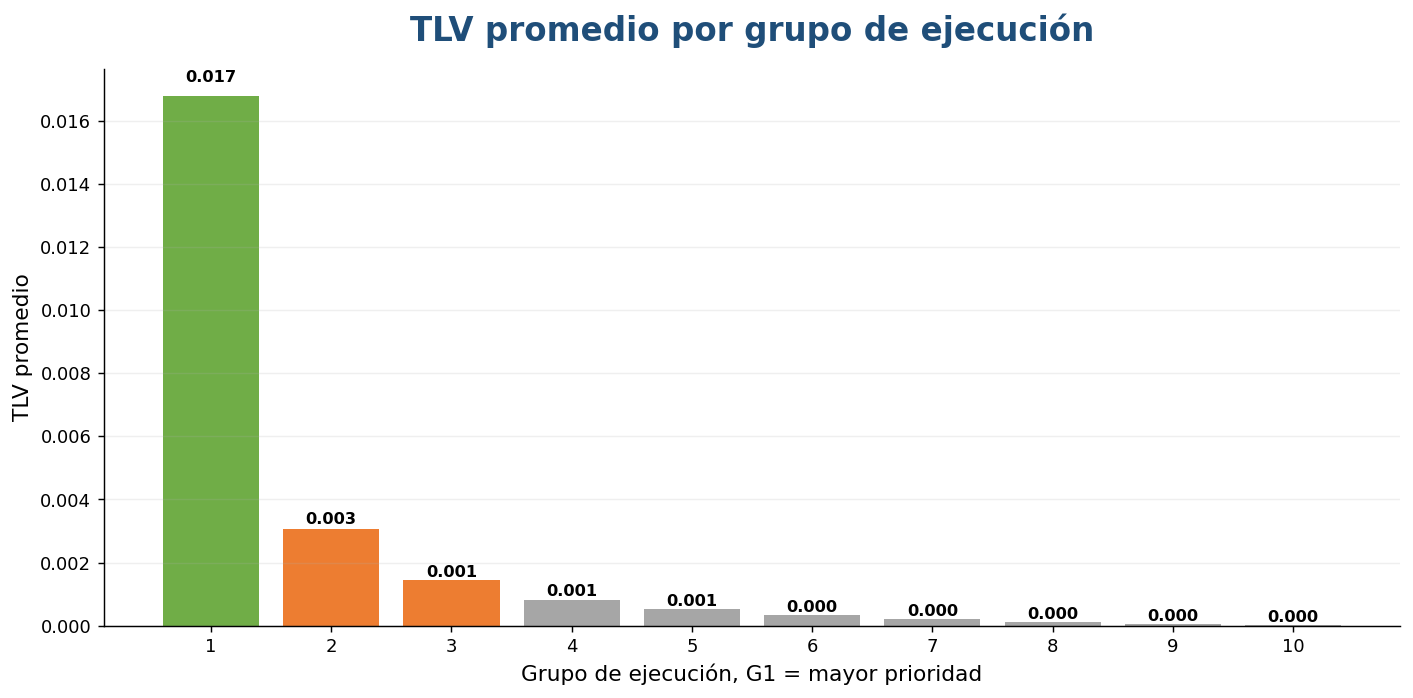


**Qué muestra:** valor comercial esperado por grupo de ejecución.  

**Interpretación:** G1 debe concentrar mayor TLV promedio y representa la primera prioridad de campaña.  

**Cómo defenderlo:** “El grupo de ejecución permite que negocio active campañas por bloques, no cliente por cliente manualmente”.


In [14]:
# ============================================================
# 13. TLV promedio por grupo de ejecución
# ============================================================

if scores is not None and tlv_col and grupo_col:
    gdf = scores.copy()
    gdf[tlv_col] = pd.to_numeric(gdf[tlv_col], errors="coerce")
    gdf = gdf.dropna(subset=[tlv_col]).copy()
    gdf[grupo_col] = gdf[grupo_col].astype(str)

    grupo_res = gdf.groupby(grupo_col, as_index=False).agg(
        tlv_promedio=(tlv_col, "mean"),
        clientes=(tlv_col, "count")
    )

    orden_extraido = grupo_res[grupo_col].str.extract(r"(\d+)")[0]
    fallback = pd.Series(np.arange(len(grupo_res)) + 1, index=grupo_res.index)
    grupo_res["orden"] = pd.to_numeric(orden_extraido, errors="coerce").fillna(fallback)
    grupo_res = grupo_res.sort_values("orden")

    guardar_tabla(grupo_res, "10_tlv_por_grupo_ejecucion.csv")

    fig, ax = plt.subplots(figsize=(11, 5.5))
    colors = [COLOR_VERDE, COLOR_NARANJA, COLOR_NARANJA] + [COLOR_GRIS] * max(0, len(grupo_res)-3)
    bars = ax.bar(grupo_res[grupo_col], grupo_res["tlv_promedio"], color=colors[:len(grupo_res)])
    titulo(ax, "TLV promedio por grupo de ejecución")
    ax.set_xlabel("Grupo de ejecución, G1 = mayor prioridad")
    ax.set_ylabel("TLV promedio")
    ax.grid(axis="y", alpha=0.20)

    for b, v in zip(bars, grupo_res["tlv_promedio"]):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.02, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    plt.tight_layout()
    guardar_figura("16_tlv_promedio_por_grupo_ejecucion.png")
    plt.show()

    display(Markdown("""
**Qué muestra:** valor comercial esperado por grupo de ejecución.  

**Interpretación:** G1 debe concentrar mayor TLV promedio y representa la primera prioridad de campaña.  

**Cómo defenderlo:** “El grupo de ejecución permite que negocio active campañas por bloques, no cliente por cliente manualmente”.
"""))
else:
    display(Markdown("No se encontró TLV o grupo de ejecución en scores."))

## 11. Monitoreo operativo desde logs

Esta gráfica lee correctamente:

- logs de entrenamiento: `training_*.log` o contenido “PIPELINE DE ENTRENAMIENTO”,
- logs de inferencia: `inference_*.log` o contenido “PIPELINE DE INFERENCIA”.

No debe duplicar el mismo tiempo para ambos pipelines.

### Tiempos detectados en logs

,archivo,tipo,tiempo_segundos,modificado
2,training_2026-05-29_20-58-13.log,entrenamiento,122.83,2026-05-29 21:00:16.389396
3,training_2026-05-29_21-00-45.log,entrenamiento,1007.05,2026-05-29 21:17:32.655993
4,training_2026-05-29_21-20-25.log,entrenamiento,104.10,2026-05-29 21:22:09.858278
0,inference_2026-05-29_21-00-24.log,inferencia,5.78,2026-05-29 21:00:30.415884
1,inference_2026-05-29_21-18-19.log,inferencia,11.52,2026-05-29 21:18:31.156437


Tabla guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling\11_tiempos_pipeline_logs.csv
Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\17_tiempo_pipeline_mlops.png


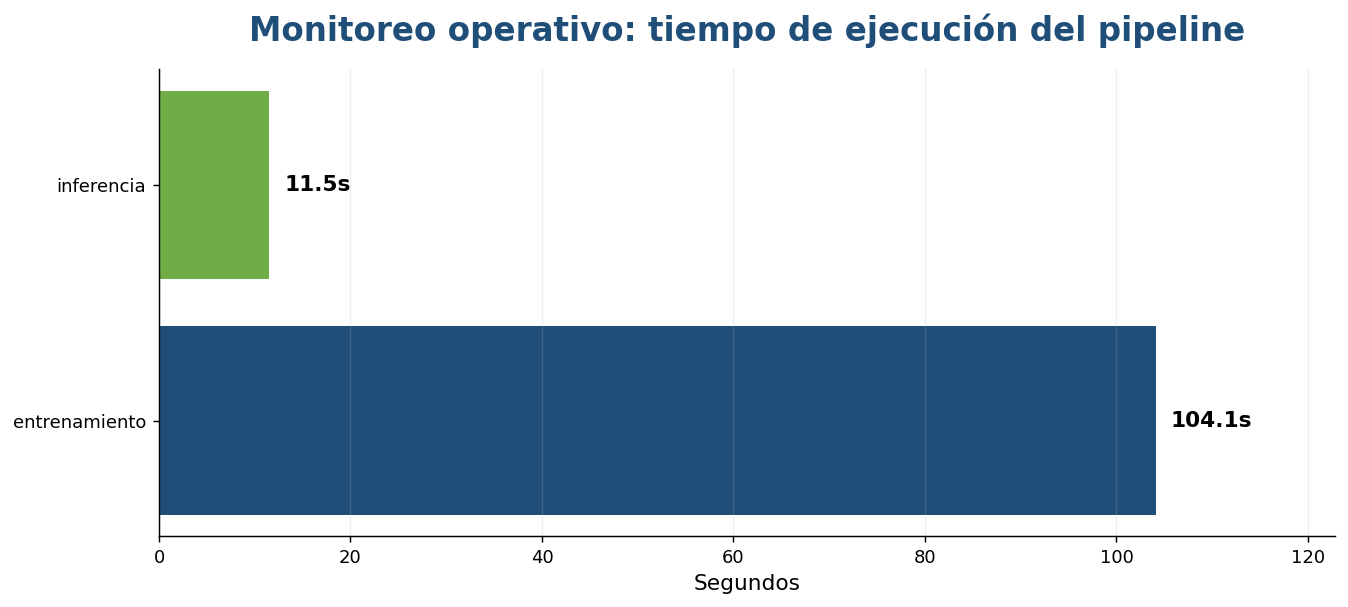


**Qué muestra:** tiempo real observado en logs para entrenamiento e inferencia.  

**Interpretación:** entrenar tarda más porque incluye ingesta, preprocesamiento, modelos, HPO, evaluación y registro. Inferir es más rápido porque usa el campeón ya registrado.  

**Cómo defenderlo:** “Además de métricas ML, registré monitoreo operativo para saber cuánto cuesta ejecutar el pipeline”.


In [15]:
# ============================================================
# 14. Monitoreo operativo: tiempo de ejecución desde logs
# ============================================================

def extraer_tiempo_log(path_log):
    texto = Path(path_log).read_text(encoding="utf-8", errors="ignore")

    patrones = [
        r"PIPELINE DE INFERENCIA COMPLETADO EN\s+([\d\.]+)\s+segundos",
        r"PIPELINE COMPLETADO EXITOSAMENTE EN\s+([\d\.]+)\s+segundos",
        r"PIPELINE DE ENTRENAMIENTO COMPLETADO EN\s+([\d\.]+)\s+segundos",
    ]

    tiempos = []
    for patron in patrones:
        tiempos += [float(x) for x in re.findall(patron, texto)]
    return tiempos[-1] if tiempos else None

def clasificar_tipo_log(path_log):
    nombre = path_log.name.lower()
    texto = path_log.read_text(encoding="utf-8", errors="ignore").lower()

    if "inference" in nombre or "inferencia" in nombre or "pipeline de inferencia" in texto:
        return "inferencia"
    if "training" in nombre or "entrenamiento" in nombre or "pipeline de entrenamiento" in texto:
        return "entrenamiento"
    return None

def obtener_tiempos_pipeline():
    registros = []
    if not DIR_LOGS.exists():
        return pd.DataFrame()

    for path_log in sorted(DIR_LOGS.glob("*.log")):
        tipo = clasificar_tipo_log(path_log)
        tiempo = extraer_tiempo_log(path_log)

        if tipo is None or tiempo is None:
            continue

        registros.append({
            "archivo": path_log.name,
            "tipo": tipo,
            "tiempo_segundos": tiempo,
            "modificado": datetime.fromtimestamp(path_log.stat().st_mtime)
        })

    return pd.DataFrame(registros)

df_tiempos = obtener_tiempos_pipeline()

if not df_tiempos.empty:
    display(Markdown("### Tiempos detectados en logs"))
    display(df_tiempos.sort_values(["tipo", "modificado"]))

    guardar_tabla(df_tiempos.sort_values(["tipo", "modificado"]), "11_tiempos_pipeline_logs.csv")

    # Para presentación: tomar el log más reciente de cada tipo.
    resumen_tiempos = (
        df_tiempos
        .sort_values("modificado")
        .groupby("tipo", as_index=False)
        .tail(1)
        .copy()
    )

    orden = ["entrenamiento", "inferencia"]
    resumen_tiempos["tipo"] = pd.Categorical(resumen_tiempos["tipo"], categories=orden, ordered=True)
    resumen_tiempos = resumen_tiempos.sort_values("tipo")

    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    colors = [COLOR_AZUL if t == "entrenamiento" else COLOR_VERDE for t in resumen_tiempos["tipo"].astype(str)]
    bars = ax.barh(resumen_tiempos["tipo"].astype(str), resumen_tiempos["tiempo_segundos"], color=colors)

    titulo(ax, "Monitoreo operativo: tiempo de ejecución del pipeline")
    ax.set_xlabel("Segundos")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.20)

    max_v = resumen_tiempos["tiempo_segundos"].max()
    for b in bars:
        v = b.get_width()
        ax.text(v + max_v * 0.015, b.get_y() + b.get_height()/2, f"{v:.1f}s",
                va="center", fontsize=12, fontweight="bold")

    ax.set_xlim(0, max_v * 1.18)
    plt.tight_layout()
    guardar_figura("17_tiempo_pipeline_mlops.png")
    plt.show()

    display(Markdown("""
**Qué muestra:** tiempo real observado en logs para entrenamiento e inferencia.  

**Interpretación:** entrenar tarda más porque incluye ingesta, preprocesamiento, modelos, HPO, evaluación y registro. Inferir es más rápido porque usa el campeón ya registrado.  

**Cómo defenderlo:** “Además de métricas ML, registré monitoreo operativo para saber cuánto cuesta ejecutar el pipeline”.
"""))
else:
    display(Markdown("No se encontraron tiempos válidos en logs."))

## Especificaciones de corrida: versión rápida vs versión completa

Esta sección documenta **qué cambia entre la corrida rápida y la corrida completa**.  
La rápida se usa para demo, validación local y revisión del profesor. La completa se usa para respaldar el resultado final con más datos y configuración más exigente.

No compara calidad del modelo directamente; documenta **configuración, reproducibilidad y costo operativo**.


Tabla guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling\14_especificaciones_corridas_rapida_vs_completa.csv


,configuracion,Archivo de configuración,Periodos entrenamiento,Periodo validación,Periodos OOT,Periodo inferencia demo,Tamaño de muestra HPO,Iteraciones HPO,Workers paralelos,Modelos evaluados,MLflow
0,Rápida,C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOp...,N/D,N/D,N/D,N/D,30000,N/D,4,"LogisticRegression, RandomForest, ExtraTrees, ...",tracking_uri: sqlite:///mlflow_store/mlflow.db...
1,Completa,C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOp...,N/D,N/D,N/D,N/D,100000,N/D,4,"LogisticRegression, RandomForest, ExtraTrees, ...",tracking_uri: sqlite:///mlflow_store/mlflow.db...


Tabla guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling\15_especificaciones_corridas_numericas.csv


,configuracion,periodos_train,periodos_oot,muestra_hpo,iteraciones_hpo,workers
0,Rápida,NaN,NaN,30000.0,NaN,4.0
1,Completa,NaN,NaN,100000.0,NaN,4.0


Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\17_especificaciones_rapida_vs_completa.png


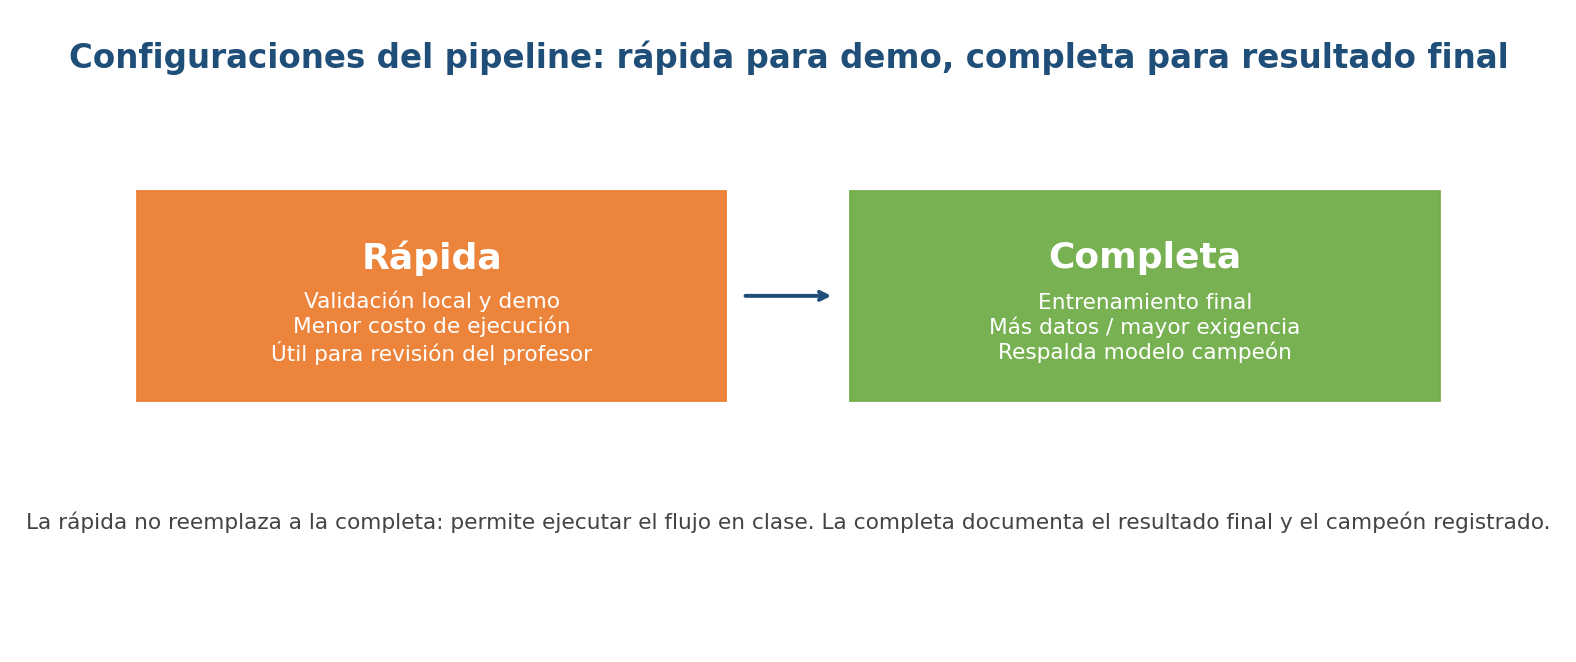


**Qué muestra:** las dos formas de ejecutar el proyecto.  

**Interpretación:** la versión rápida permite demostrar reproducibilidad sin esperar toda la corrida; la versión completa respalda el resultado final del modelo campeón.  

**Cómo defenderlo:** “Diseñé dos configuraciones porque un pipeline MLOps debe ser reproducible y ejecutable localmente. La rápida sirve para demo y la completa para el resultado final registrado”.


In [16]:
# ============================================================
# Especificaciones de corrida: rápida vs completa
# ============================================================
# Lee config/config_rapido.yaml y config/config_completo.yaml cuando existen.
# También intenta config.yaml y config_full.yaml.
# Esta sección sirve para explicar la lógica de ejecución ante el profesor.

def cargar_yaml_seguro(path):
    try:
        import yaml
    except Exception as e:
        return None, f"No se pudo importar PyYAML. Instala con: python -m pip install PyYAML. Detalle: {e}"

    try:
        with open(path, "r", encoding="utf-8") as f:
            return yaml.safe_load(f), None
    except Exception as e:
        return None, str(e)

def buscar_config(nombre_preferido, alternativos):
    candidatos = [PROJECT_ROOT / "config" / nombre_preferido]
    candidatos += [PROJECT_ROOT / "config" / x for x in alternativos]
    for p in candidatos:
        if p.exists():
            return p
    return None

config_rapida_path = buscar_config("config_rapido.yaml", ["config.yaml", "config_base.yaml"])
config_completa_path = buscar_config("config_completo.yaml", ["config_full.yaml", "config_completa.yaml"])

configs = []
for etiqueta, path_cfg in [("Rápida", config_rapida_path), ("Completa", config_completa_path)]:
    if path_cfg is None:
        configs.append({"configuracion": etiqueta, "archivo_config": "No encontrado", "config": None, "error": "No encontrado"})
    else:
        cfg, err = cargar_yaml_seguro(path_cfg)
        configs.append({"configuracion": etiqueta, "archivo_config": str(path_cfg), "config": cfg, "error": err})

def buscar_valor_recursivo(obj, claves_posibles):
    if obj is None:
        return None
    if isinstance(obj, dict):
        for k, v in obj.items():
            if str(k).lower() in [c.lower() for c in claves_posibles]:
                return v
        for v in obj.values():
            res = buscar_valor_recursivo(v, claves_posibles)
            if res is not None:
                return res
    return None

def formato_valor(v):
    if v is None:
        return "N/D"
    if isinstance(v, (list, tuple)):
        return ", ".join(map(str, v))
    if isinstance(v, dict):
        partes = []
        for k, val in list(v.items())[:6]:
            partes.append(f"{k}: {val}")
        return "; ".join(partes)
    return str(v)

campos = [
    ("Archivo de configuración", None),
    ("Periodos entrenamiento", ["train_periods", "training_periods", "periodos_train", "periodos_entrenamiento"]),
    ("Periodo validación", ["valid_period", "validation_period", "periodo_validacion", "valid_periods"]),
    ("Periodos OOT", ["oot_periods", "periodos_oot", "oot_period"]),
    ("Periodo inferencia demo", ["inference_period", "periodo_inferencia", "period"]),
    ("Tamaño de muestra HPO", ["hpo_sample_size", "sample_size_hpo", "hpo_sample", "muestra_hpo"]),
    ("Iteraciones HPO", ["n_iter", "n_calls", "hpo_iterations", "iteraciones_hpo"]),
    ("Workers paralelos", ["max_workers", "workers", "n_jobs", "parallel_workers"]),
    ("Modelos evaluados", ["models", "modelos"]),
    ("MLflow", ["mlflow", "use_mlflow", "tracking"]),
]

filas_specs = []
for c in configs:
    cfg = c["config"]
    fila = {"configuracion": c["configuracion"]}
    for nombre_campo, claves in campos:
        if nombre_campo == "Archivo de configuración":
            fila[nombre_campo] = c["archivo_config"]
        else:
            fila[nombre_campo] = formato_valor(buscar_valor_recursivo(cfg, claves))
    filas_specs.append(fila)

df_specs = pd.DataFrame(filas_specs)
guardar_tabla(df_specs, "14_especificaciones_corridas_rapida_vs_completa.csv")
display(df_specs)

def contar_periodos(v):
    if isinstance(v, (list, tuple)):
        return len(v)
    if v is None:
        return np.nan
    try:
        return len([x for x in str(v).split(",") if x.strip()])
    except Exception:
        return np.nan

def a_num(v):
    try:
        if isinstance(v, bool) or isinstance(v, (list, tuple, dict)):
            return np.nan
        return float(v)
    except Exception:
        return np.nan

resumen_num = []
for c in configs:
    cfg = c["config"]
    etiqueta = c["configuracion"]
    train_periods = buscar_valor_recursivo(cfg, ["train_periods", "training_periods", "periodos_train", "periodos_entrenamiento"])
    oot_periods = buscar_valor_recursivo(cfg, ["oot_periods", "periodos_oot", "oot_period"])
    hpo_sample = buscar_valor_recursivo(cfg, ["hpo_sample_size", "sample_size_hpo", "hpo_sample", "muestra_hpo"])
    n_iter = buscar_valor_recursivo(cfg, ["n_iter", "n_calls", "hpo_iterations", "iteraciones_hpo"])
    workers = buscar_valor_recursivo(cfg, ["max_workers", "workers", "n_jobs", "parallel_workers"])
    resumen_num.append({
        "configuracion": etiqueta,
        "periodos_train": contar_periodos(train_periods),
        "periodos_oot": contar_periodos(oot_periods),
        "muestra_hpo": a_num(hpo_sample),
        "iteraciones_hpo": a_num(n_iter),
        "workers": a_num(workers),
    })

df_specs_num = pd.DataFrame(resumen_num)
guardar_tabla(df_specs_num, "15_especificaciones_corridas_numericas.csv")
display(df_specs_num)

fig, ax = plt.subplots(figsize=(13.5, 5.2))
ax.axis("off")

ax.text(
    0.5, 0.93,
    "Configuraciones del pipeline: rápida para demo, completa para resultado final",
    ha="center", va="center",
    fontsize=18, fontweight="bold",
    color=COLOR_AZUL, transform=ax.transAxes
)

tarjetas = [
    ("Rápida", "Validación local y demo\nMenor costo de ejecución\nÚtil para revisión del profesor", COLOR_NARANJA),
    ("Completa", "Entrenamiento final\nMás datos / mayor exigencia\nRespalda modelo campeón", COLOR_VERDE),
]

for i, (titulo_tarjeta, cuerpo, color) in enumerate(tarjetas):
    x = 0.08 + i * 0.46
    y = 0.39
    w = 0.38
    h = 0.33
    rect = plt.Rectangle((x, y), w, h, transform=ax.transAxes, color=color, alpha=0.95)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h*0.68, titulo_tarjeta, ha="center", va="center", fontsize=20, fontweight="bold", color="white", transform=ax.transAxes)
    ax.text(x + w/2, y + h*0.35, cuerpo, ha="center", va="center", fontsize=12, color="white", transform=ax.transAxes)

ax.annotate(
    "",
    xy=(0.53, 0.555),
    xytext=(0.47, 0.555),
    xycoords=ax.transAxes,
    arrowprops=dict(arrowstyle="->", lw=2.2, color=COLOR_AZUL),
    annotation_clip=False
)

ax.text(
    0.5, 0.20,
    "La rápida no reemplaza a la completa: permite ejecutar el flujo en clase. La completa documenta el resultado final y el campeón registrado.",
    ha="center", va="center",
    fontsize=12,
    color="#444444",
    transform=ax.transAxes
)

plt.tight_layout(pad=1)
guardar_figura("17_especificaciones_rapida_vs_completa.png")
plt.show()

display(Markdown("""
**Qué muestra:** las dos formas de ejecutar el proyecto.  

**Interpretación:** la versión rápida permite demostrar reproducibilidad sin esperar toda la corrida; la versión completa respalda el resultado final del modelo campeón.  

**Cómo defenderlo:** “Diseñé dos configuraciones porque un pipeline MLOps debe ser reproducible y ejecutable localmente. La rápida sirve para demo y la completa para el resultado final registrado”.
"""))

## 12. Monitoreo operativo: eficiencia por paralelismo

Esta sección no mide calidad predictiva. Mide **eficiencia operacional**: cuánto se acelera el entrenamiento cuando los modelos se entrenan en paralelo frente a entrenarlos de forma secuencial.

La fórmula usada es:

$$\text{speed-up} = \frac{\text{tiempo secuencial}}{\text{tiempo paralelo}}$$

Esto responde al criterio de MLOps de **escalabilidad y monitoreo operativo** solicitado en el parcial.


Tabla guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling\13_speedup_paralelismo_logs.csv


,experimento,tiempo_secuencial_seg,tiempo_paralelo_seg,speedup,reduccion_tiempo_pct,archivo
0,Rápido,39.07,26.77,1.460,31.481955,training_2026-05-29_21-20-25.log
1,Completo,448.12,300.22,1.493,33.004552,training_2026-05-29_21-00-45.log


Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\18_speedup_paralelismo_secuencial_vs_paralelo.png


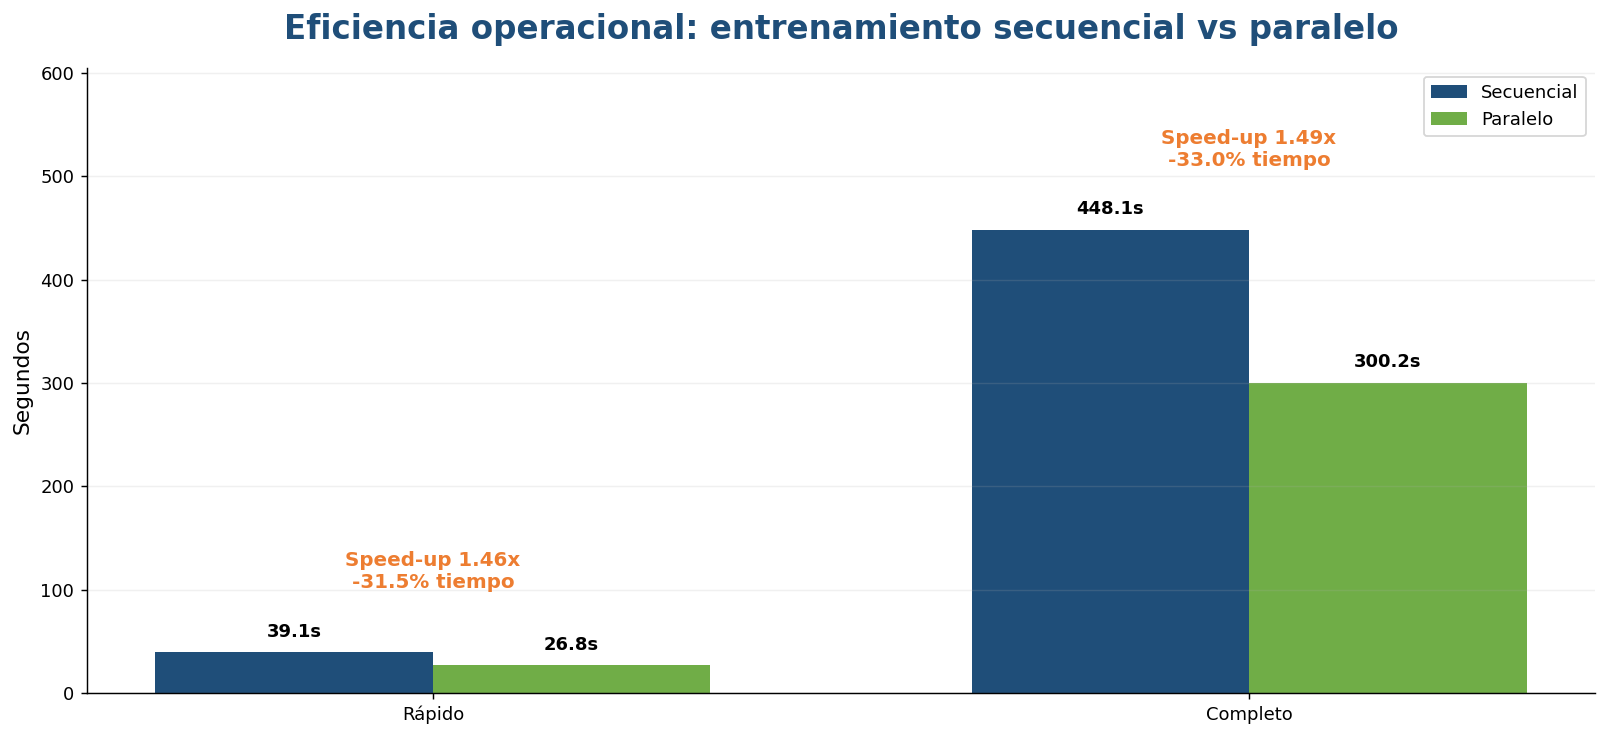

Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\19_speedup_paralelismo_resumen.png


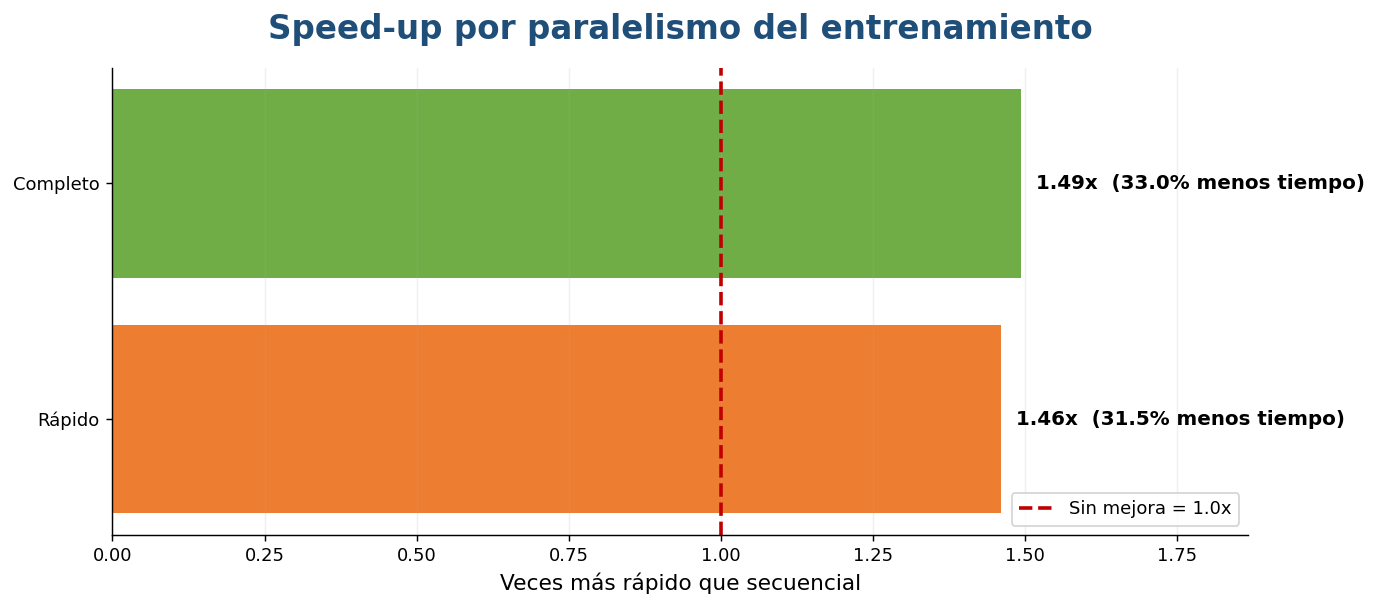


**Qué muestra:** compara el entrenamiento secuencial contra el entrenamiento paralelo por tipo de corrida.  

**Interpretación:** el speed-up mide eficiencia operacional. No mide AUC ni calidad del modelo.  

**Cómo defenderlo:** “El pipeline entrena modelos en paralelo con `ProcessPoolExecutor`. Esto reduce el tiempo de la etapa de entrenamiento base frente a una ejecución secuencial. En la corrida rápida y en la completa se registra el speed-up como evidencia de escalabilidad operativa”.  

**Por qué no aparece 12x aunque existan 12 núcleos:** no todo el pipeline es paralelizable. Hay pasos secuenciales: ingesta, preprocesamiento, HPO, evaluación, guardado y registro.


In [17]:
# ============================================================
# 12. Monitoreo operativo: eficiencia por paralelismo
# ============================================================
# Corrección:
# - Lee TODO el log para clasificar Rápido / Completo.
# - No depende solo de las líneas cercanas a "Speedup".
# - Conserva una fila por cada tipo de corrida si existen ambas.

def clasificar_experimento_log(nombre_log, texto):
    nombre = str(nombre_log).lower()
    texto_low = str(texto).lower()

    m_exp = re.search(r"experimento\s*:\s*([^\n\r]+)", texto_low)
    if m_exp:
        exp = m_exp.group(1).strip()
        if "rapido" in exp or "rápido" in exp or "base" in exp:
            return "Rápido"
        if "completo" in exp or "full" in exp:
            return "Completo"

    m_cfg = re.search(r"config\s+usado\s*:\s*([^\n\r]+)", texto_low)
    if m_cfg:
        cfg = m_cfg.group(1).strip()
        if "completo" in cfg or "full" in cfg:
            return "Completo"
        if "rapido" in cfg or "rápido" in cfg or cfg.endswith("config.yaml"):
            return "Rápido"

    m_train = re.search(r"train\s*:\s*\((\d+)\s*,", texto_low)
    if m_train:
        n_train = int(m_train.group(1))
        if n_train >= 300000:
            return "Completo"
        if n_train <= 100000:
            return "Rápido"

    if any(x in nombre for x in ["rapido", "rápido", "quick", "fast", "base"]):
        return "Rápido"
    if any(x in nombre for x in ["completo", "full", "total"]):
        return "Completo"

    return "No identificado"

def extraer_speedups_paralelismo():
    registros = []

    if not DIR_LOGS.exists():
        return pd.DataFrame()

    patron = re.compile(
        r"tiempo\s+secuencial\s*:\s*([\d\.]+).*?"
        r"tiempo\s+paralelo\s*:\s*([\d\.]+).*?"
        r"speedup\s*:\s*([\d\.]+)\s*x?",
        flags=re.IGNORECASE | re.DOTALL
    )

    for log_path in sorted(DIR_LOGS.glob("training_*.log")):
        texto = log_path.read_text(encoding="utf-8", errors="ignore")
        experimento = clasificar_experimento_log(log_path.name, texto)

        for m in patron.finditer(texto):
            tiempo_sec = float(m.group(1))
            tiempo_par = float(m.group(2))
            speed = float(m.group(3))
            registros.append({
                "experimento": experimento,
                "tiempo_secuencial_seg": tiempo_sec,
                "tiempo_paralelo_seg": tiempo_par,
                "speedup": speed,
                "reduccion_tiempo_pct": 100 * (1 - tiempo_par / tiempo_sec) if tiempo_sec else np.nan,
                "archivo": log_path.name,
                "modificado": datetime.fromtimestamp(log_path.stat().st_mtime),
            })

    df = pd.DataFrame(registros)

    if df.empty:
        return df

    df = df.drop_duplicates(
        subset=["archivo", "tiempo_secuencial_seg", "tiempo_paralelo_seg", "speedup"]
    )

    orden = {"Rápido": 1, "Completo": 2, "No identificado": 9}
    df["orden"] = df["experimento"].map(orden).fillna(9)

    df = (
        df.sort_values(["orden", "modificado"])
          .groupby("experimento", as_index=False)
          .tail(1)
          .sort_values("orden")
          .drop(columns=["orden"])
          .reset_index(drop=True)
    )

    return df

df_speedup = extraer_speedups_paralelismo()

if df_speedup.empty:
    display(Markdown("""
### No se encontró speed-up de paralelismo en los logs

El notebook buscó líneas como:

- `Tiempo secuencial: 473.11`
- `Tiempo paralelo: 370.25`
- `Speedup: 1.278x`

Si el pipeline no escribe esas líneas, la gráfica no puede calcularse automáticamente.
"""))
else:
    guardar_tabla(df_speedup, "13_speedup_paralelismo_logs.csv")
    display(df_speedup[[
        "experimento",
        "tiempo_secuencial_seg",
        "tiempo_paralelo_seg",
        "speedup",
        "reduccion_tiempo_pct",
        "archivo",
    ]])

    fig, ax = plt.subplots(figsize=(12.5, 5.8))
    x = np.arange(len(df_speedup))
    width = 0.34

    b1 = ax.bar(x - width/2, df_speedup["tiempo_secuencial_seg"], width, label="Secuencial", color=COLOR_AZUL)
    b2 = ax.bar(x + width/2, df_speedup["tiempo_paralelo_seg"], width, label="Paralelo", color=COLOR_VERDE)

    titulo(ax, "Eficiencia operacional: entrenamiento secuencial vs paralelo")
    ax.set_ylabel("Segundos")
    ax.set_xticks(x)
    ax.set_xticklabels(df_speedup["experimento"])
    ax.grid(axis="y", alpha=0.18)
    ax.legend(loc="upper right")

    max_y = max(df_speedup["tiempo_secuencial_seg"].max(), df_speedup["tiempo_paralelo_seg"].max())

    for bars in [b1, b2]:
        for b in bars:
            v = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, v + max_y * 0.025, f"{v:.1f}s",
                    ha="center", va="bottom", fontsize=10, fontweight="bold")

    for i, r in df_speedup.iterrows():
        ax.text(
            i,
            max(r["tiempo_secuencial_seg"], r["tiempo_paralelo_seg"]) + max_y * 0.13,
            f"Speed-up {r['speedup']:.2f}x\n-{r['reduccion_tiempo_pct']:.1f}% tiempo",
            ha="center", va="bottom",
            fontsize=11,
            fontweight="bold",
            color=COLOR_NARANJA
        )

    ax.set_ylim(0, max_y * 1.35)
    plt.tight_layout()
    guardar_figura("18_speedup_paralelismo_secuencial_vs_paralelo.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(10.8, 4.8))
    colors = [COLOR_NARANJA if e == "Rápido" else COLOR_VERDE if e == "Completo" else COLOR_GRIS for e in df_speedup["experimento"]]
    bars = ax.barh(df_speedup["experimento"], df_speedup["speedup"], color=colors)

    titulo(ax, "Speed-up por paralelismo del entrenamiento")
    ax.set_xlabel("Veces más rápido que secuencial")
    ax.axvline(1.0, color=COLOR_ROJO, linestyle="--", lw=2, label="Sin mejora = 1.0x")
    ax.grid(axis="x", alpha=0.18)
    ax.legend(loc="lower right")

    for b, r in zip(bars, df_speedup.itertuples()):
        v = b.get_width()
        ax.text(v + 0.025, b.get_y() + b.get_height()/2,
                f"{v:.2f}x  ({r.reduccion_tiempo_pct:.1f}% menos tiempo)",
                va="center", fontsize=11, fontweight="bold")

    ax.set_xlim(0, max(1.6, df_speedup["speedup"].max() * 1.25))
    plt.tight_layout()
    guardar_figura("19_speedup_paralelismo_resumen.png")
    plt.show()

    display(Markdown("""
**Qué muestra:** compara el entrenamiento secuencial contra el entrenamiento paralelo por tipo de corrida.  

**Interpretación:** el speed-up mide eficiencia operacional. No mide AUC ni calidad del modelo.  

**Cómo defenderlo:** “El pipeline entrena modelos en paralelo con `ProcessPoolExecutor`. Esto reduce el tiempo de la etapa de entrenamiento base frente a una ejecución secuencial. En la corrida rápida y en la completa se registra el speed-up como evidencia de escalabilidad operativa”.  

**Por qué no aparece 12x aunque existan 12 núcleos:** no todo el pipeline es paralelizable. Hay pasos secuenciales: ingesta, preprocesamiento, HPO, evaluación, guardado y registro.
"""))

## 12. Anexo técnico: variables individuales

Este gráfico sirve para preguntas técnicas.  
Para la presentación ejecutiva conviene explicar por familias; para defensa técnica se puede mostrar top variables individuales.

Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\18_anexo_top_variables_individuales.png


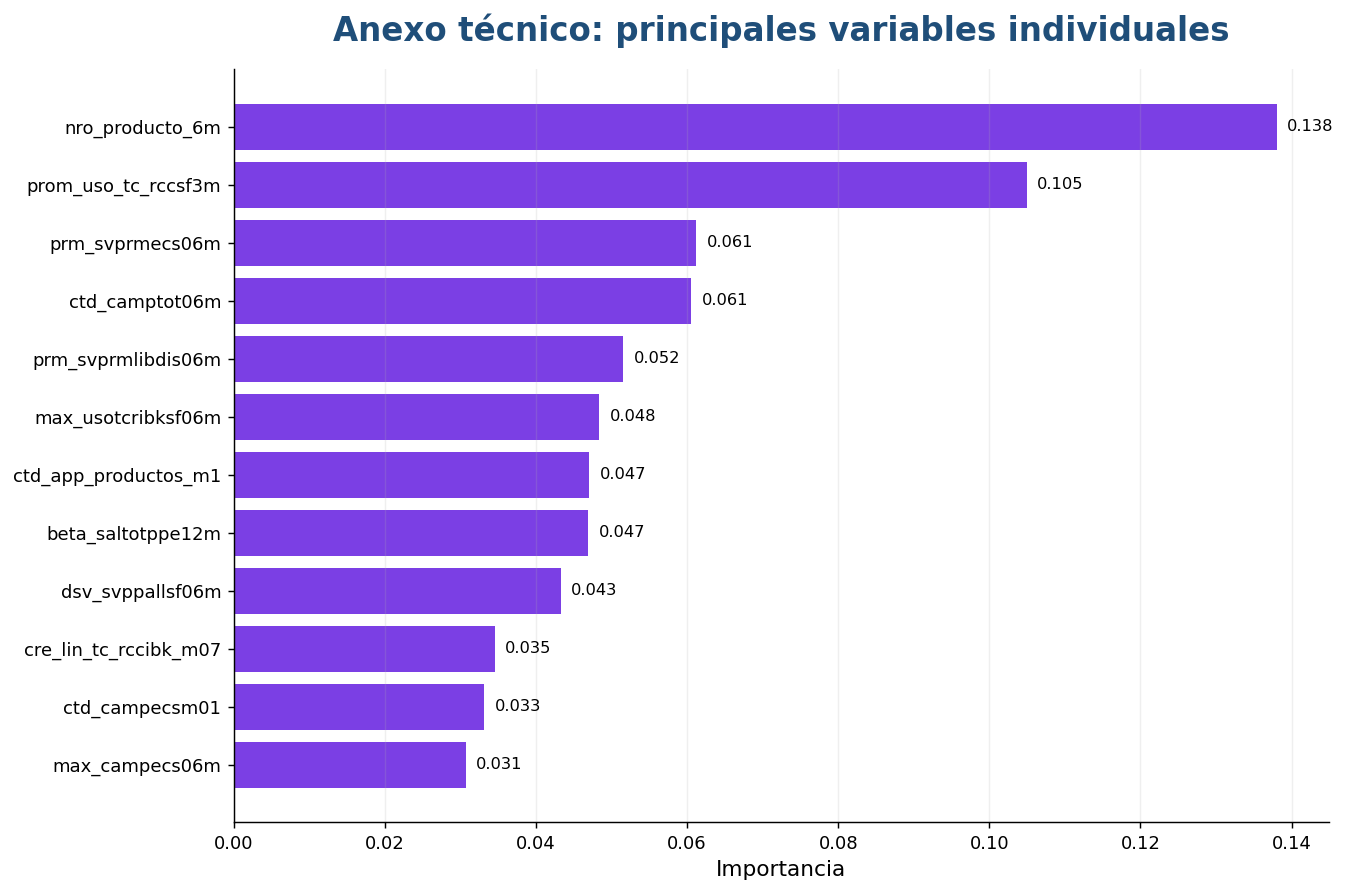


**Qué muestra:** variables individuales con mayor aporte al modelo.  

**Interpretación:** sirve como soporte técnico; la explicación principal debe seguir siendo por familias de negocio.  

**Cuidado técnico:** no afirmar causalidad; hablar de importancia predictiva.


In [18]:
# ============================================================
# 15. Anexo técnico: variables individuales más importantes
# ============================================================

if importancia_vars is not None:
    iv = importancia_vars.copy()
    rename = {}
    for c in iv.columns:
        cl = c.lower()
        if cl in ["variable", "feature", "columna"]:
            rename[c] = "variable"
        elif "import" in cl or "peso" in cl:
            rename[c] = "importancia"
    iv = iv.rename(columns=rename)

    if {"variable", "importancia"}.issubset(iv.columns):
        iv = iv[["variable", "importancia"]].dropna()
        iv = iv.sort_values("importancia", ascending=False).head(12).sort_values("importancia", ascending=True)

        fig, ax = plt.subplots(figsize=(10.5, 7))
        bars = ax.barh(iv["variable"], iv["importancia"], color=COLOR_MORADO)
        titulo(ax, "Anexo técnico: principales variables individuales")
        ax.set_xlabel("Importancia")
        ax.grid(axis="x", alpha=0.20)

        for b, v in zip(bars, iv["importancia"]):
            ax.text(v + iv["importancia"].max()*0.01, b.get_y()+b.get_height()/2, f"{v:.3f}",
                    va="center", fontsize=9)

        plt.tight_layout()
        guardar_figura("18_anexo_top_variables_individuales.png")
        plt.show()

        display(Markdown("""
**Qué muestra:** variables individuales con mayor aporte al modelo.  

**Interpretación:** sirve como soporte técnico; la explicación principal debe seguir siendo por familias de negocio.  

**Cuidado técnico:** no afirmar causalidad; hablar de importancia predictiva.
"""))
    else:
        display(Markdown("La tabla de importancia individual no tiene columnas reconocibles."))
else:
    display(Markdown("No se encontró tabla de importancia individual."))

## 13. Resumen ejecutivo de KPIs

Esta sección arma una lámina de cierre con los indicadores principales para PPT.

Tabla guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\tables_storytelling\12_resumen_ejecutivo_kpis.csv


,KPI,Valor
0,Modelo campeón,GradientBoosting
1,AUC OOT,0.858
2,Gap OOT,0.0168
3,Lift D1,N/D
4,Tasa D1,N/D
5,Captura D1-D3,N/D
6,Data experimento,720.000 filas
7,Variables,69 vars / 9 familias
8,Tiempo inferencia,11.5s


Figura guardada: C:\Users\uzzie\Downloads\Proyecto_Parcial_MLOps_GariazzoHH\Proyecto_Parcial_MLOps_Gariazzo_FINAL\reports\figures_storytelling\19_resumen_ejecutivo_kpis.png


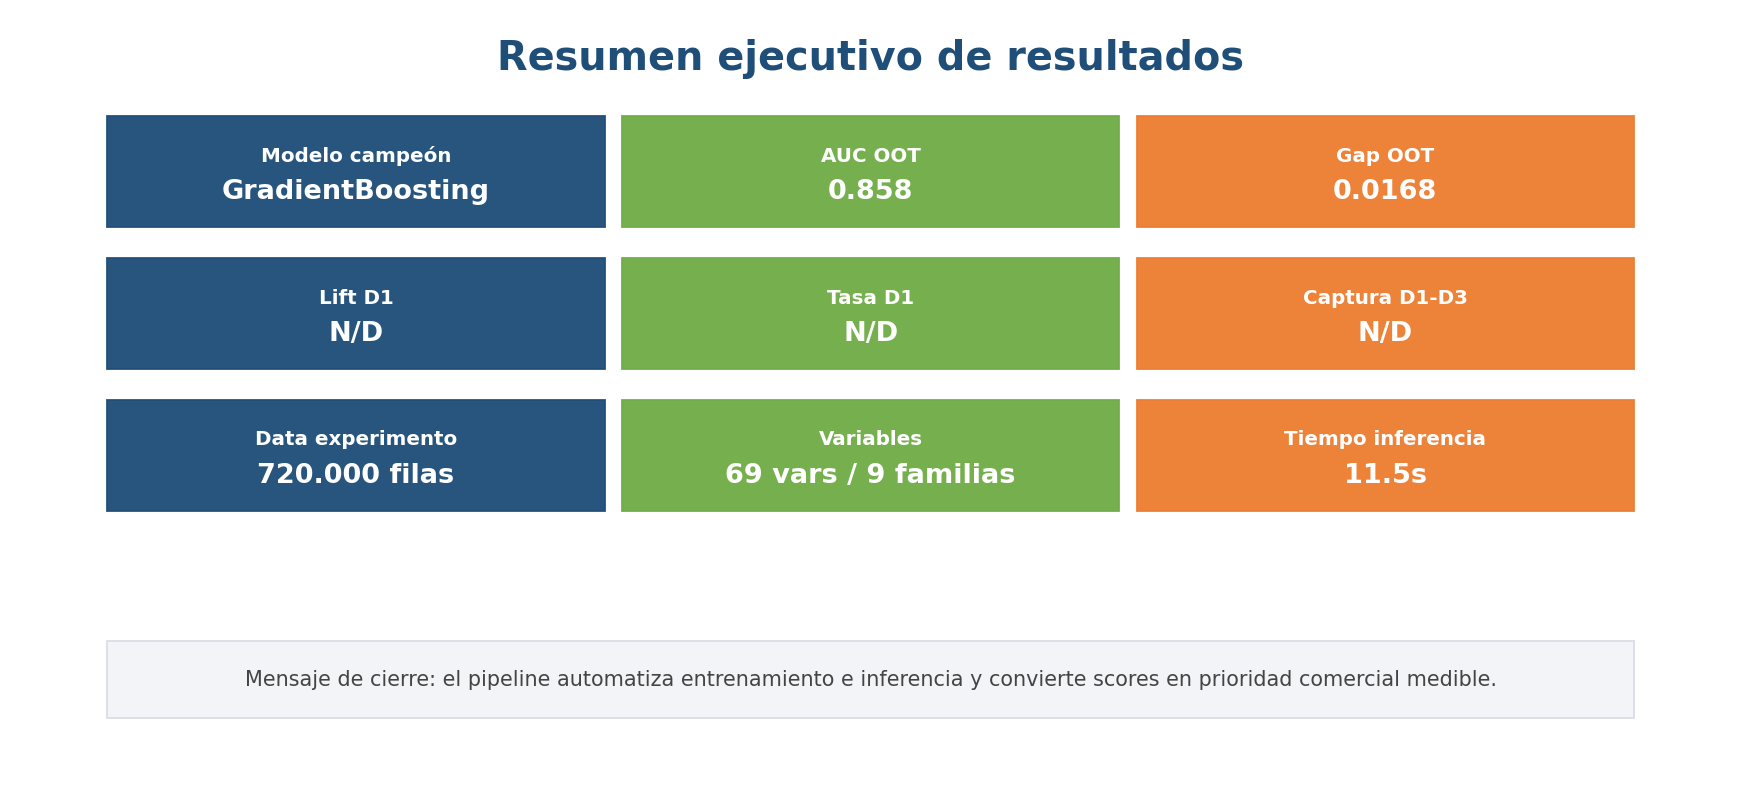


**Cómo usar esta lámina:** sirve como cierre de la presentación de 5 minutos.  
Resume estabilidad, valor comercial, volumen de datos, variables y monitoreo operativo.


In [19]:
# ============================================================
# 16. Resumen ejecutivo de KPIs
# ============================================================
# Corrección v7:
# - El título queda arriba y no invade las tarjetas.
# - Las tarjetas empiezan más abajo.
# - Se usa una tarjeta de texto final separada para evitar que el pie quede suelto.

def obtener_campeon():
    if isinstance(registry, dict):
        for key in ["champion", "campeon", "modelo_campeon", "current_champion"]:
            if key in registry:
                val = registry[key]
                if isinstance(val, dict):
                    return val.get("model_name") or val.get("modelo") or val.get("name")
                return str(val)

    if lb is not None and "modelo" in lb.columns:
        if "auc_test" in lb.columns:
            return lb.sort_values("auc_test", ascending=False).iloc[0]["modelo"]
        return lb.iloc[0]["modelo"]
    return "Campeón"

campeon = obtener_campeon()

auc_oot_val = None
gap_val = None
if lb is not None and "modelo" in lb.columns:
    fila = lb[lb["modelo"].astype(str).str.lower() == str(campeon).lower()]
    if fila.empty:
        fila = lb.sort_values("auc_test", ascending=False).head(1) if "auc_test" in lb.columns else lb.head(1)
    fila = fila.iloc[0]
    auc_oot_val = fila.get("auc_oot", None)
    gap_val = fila.get("gap", None)

lift_d1 = None
captura_d3 = None
tasa_d1 = None
if "decil_eval" in globals():
    try:
        d1 = decil_eval[decil_eval["orden"] == 1].iloc[0]
        lift_d1 = d1["lift"]
        tasa_d1 = d1["tasa_compra"]
        d3 = decil_eval[decil_eval["orden"] == 3].iloc[0]
        captura_d3 = d3["pct_compradores_acum"]
    except Exception:
        pass

tiempo_inf = None
tiempo_train = None
if "resumen_tiempos" in globals():
    try:
        for _, r in resumen_tiempos.iterrows():
            if str(r["tipo"]) == "inferencia":
                tiempo_inf = r["tiempo_segundos"]
            if str(r["tipo"]) == "entrenamiento":
                tiempo_train = r["tiempo_segundos"]
    except Exception:
        pass

filas_exp = None
if "split_exp" in globals():
    try:
        filas_exp = int(split_exp["filas"].sum())
    except Exception:
        pass

n_vars = sum(df_familias["cantidad_variables"]) if "df_familias" in globals() else None
n_fam = len(df_familias) if "df_familias" in globals() else None

kpi_items = [
    ("Modelo campeón", str(campeon)),
    ("AUC OOT", f"{auc_oot_val:.3f}" if auc_oot_val is not None and pd.notna(auc_oot_val) else "N/D"),
    ("Gap OOT", f"{gap_val:.4f}" if gap_val is not None and pd.notna(gap_val) else "N/D"),
    ("Lift D1", f"{lift_d1:.1f}x" if lift_d1 is not None and pd.notna(lift_d1) else "N/D"),
    ("Tasa D1", f"{tasa_d1:.1%}" if tasa_d1 is not None and pd.notna(tasa_d1) else "N/D"),
    ("Captura D1-D3", f"{captura_d3:.1%}" if captura_d3 is not None and pd.notna(captura_d3) else "N/D"),
    ("Data experimento", f"{filas_exp:,} filas".replace(",", ".") if filas_exp else "N/D"),
    ("Variables", f"{n_vars} vars / {n_fam} familias" if n_vars else "N/D"),
    ("Tiempo inferencia", f"{tiempo_inf:.1f}s" if tiempo_inf is not None else "N/D"),
]

df_kpi_final = pd.DataFrame(kpi_items, columns=["KPI", "Valor"])
guardar_tabla(df_kpi_final, "12_resumen_ejecutivo_kpis.csv")
display(df_kpi_final)

fig, ax = plt.subplots(figsize=(13.5, 6.2))
ax.axis("off")

# Título separado de las tarjetas.
ax.text(
    0.5, 0.94,
    "Resumen ejecutivo de resultados",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold",
    color=COLOR_AZUL,
    transform=ax.transAxes
)

cols = 3
box_w = 0.29
box_h = 0.145
x_positions = [0.055, 0.355, 0.655]
y_start = 0.72
row_gap = 0.185

for idx, (k, v) in enumerate(kpi_items):
    row = idx // cols
    col = idx % cols
    x = x_positions[col]
    y = y_start - row * row_gap
    color = [COLOR_AZUL, COLOR_VERDE, COLOR_NARANJA][col % 3]
    rect = plt.Rectangle((x, y), box_w, box_h, transform=ax.transAxes, color=color, alpha=0.96)
    ax.add_patch(rect)

    ax.text(
        x + box_w/2, y + box_h*0.64,
        k,
        ha="center",
        va="center",
        fontsize=11,
        color="white",
        fontweight="bold",
        transform=ax.transAxes
    )
    ax.text(
        x + box_w/2, y + box_h*0.32,
        v,
        ha="center",
        va="center",
        fontsize=15,
        color="white",
        fontweight="bold",
        transform=ax.transAxes
    )

# Caja final de mensaje, alineada y sin superposición.
msg_y = 0.08
msg_rect = plt.Rectangle((0.055, msg_y), 0.89, 0.10, transform=ax.transAxes, color="#f2f4f7", ec="#d9dee7")
ax.add_patch(msg_rect)
ax.text(
    0.5,
    msg_y + 0.05,
    "Mensaje de cierre: el pipeline automatiza entrenamiento e inferencia y convierte scores en prioridad comercial medible.",
    ha="center",
    va="center",
    fontsize=11.5,
    color="#444444",
    transform=ax.transAxes
)

plt.tight_layout(pad=1.0)
guardar_figura("19_resumen_ejecutivo_kpis.png")
plt.show()

display(Markdown("""
**Cómo usar esta lámina:** sirve como cierre de la presentación de 5 minutos.  
Resume estabilidad, valor comercial, volumen de datos, variables y monitoreo operativo.
"""))

# Cierre para sustentación

Frase final sugerida:

> “El proyecto implementa un pipeline completo de MLOps: ingesta, preprocesamiento, entrenamiento con HPO, evaluación temporal, registro del campeón, inferencia y postprocesamiento comercial. El modelo no entrega solo probabilidades; transforma el score en una priorización accionable mediante TLV y grupos de ejecución. Además, se registran métricas operativas como tiempo de ejecución y speed-up por paralelismo, lo que permite sustentar reproducibilidad, eficiencia y escalabilidad.”
